In [4]:
"""
CELL 1: Import Libraries
-----------------------
Purpose: Load all Python libraries needed for Instagram analytics
"""

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr, f_oneway

# Date handling
from datetime import datetime
import calendar

# For better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
sns.set_style("whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

✅ Libraries imported successfully!
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


In [5]:
"""
CELL 2: Load Instagram Data
-------------------------
"""

df = pd.read_csv('G:\Data Analysis projects\Python Projects\Instagram analysis\Instagram_Analytics.csv')  

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of posts: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

print("\n" + "="*60)
print("FIRST 5 POSTS:")
print("="*60)
df.head()

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3833651935.py:6: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('G:\Data Analysis projects\Python Projects\Instagram analysis\Instagram_Analytics.csv')


Data loaded successfully!
Dataset shape: (29999, 23)
Number of posts: 29,999
Number of columns: 23

FIRST 5 POSTS:


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,post_hour,day_of_week,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,6,Saturday,194,5,7,34,4327,6230,0.04,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,15,Friday,449,10,21,68,7451,8268,0.07,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,16,Thursday,114,2,1,22,1639,2616,0.05,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,3,Thursday,91,0,7,0,2877,3171,0.03,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,9,Friday,154,8,5,21,5350,8503,0.02,155,112,9,low


In [6]:
"""
CELL 3: Dataset Overview
----------------------
Purpose: Understand data types, missing values, and basic statistics
"""

print("DATASET INFORMATION:")
print("="*60)
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Column names: {list(df.columns)}")

print("\nDATA TYPES:")
print("="*60)
print(df.dtypes)

print("\nMISSING VALUES:")
print("="*60)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0] if any(missing_values > 0) else "No missing values found!")

print("\nBASIC STATISTICS (Numerical Columns):")
print("="*60)
df.describe()

print("\nCATEGORICAL COLUMNS SUMMARY:")
print("="*60)
categorical_cols = ['account_type', 'media_type', 'content_category', 'traffic_source', 
                    'has_call_to_action', 'day_of_week', 'performance_bucket_label']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(df[col].value_counts().head())

DATASET INFORMATION:
Total rows: 29999
Total columns: 23
Column names: ['post_id', 'account_id', 'account_type', 'follower_count', 'media_type', 'content_category', 'traffic_source', 'has_call_to_action', 'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained', 'caption_length', 'hashtags_count', 'performance_bucket_label']

DATA TYPES:
post_id                      object
account_id                    int64
account_type                 object
follower_count                int64
media_type                   object
                             ...   
engagement_rate             float64
followers_gained              int64
caption_length                int64
hashtags_count                int64
performance_bucket_label     object
Length: 23, dtype: object

MISSING VALUES:
No missing values found!

BASIC STATISTICS (Numerical Columns):

CATEGORICAL COLUMNS SUMMARY:

ACCOUNT_TYPE:
account_t

In [7]:
"""
CELL 4: Data Cleaning and Feature Engineering
------------------------------------------
Purpose: Clean the data and create new features for analysis
"""

# Create a cleaned copy
df_clean = df.copy()

# 1. Convert post_datetime to datetime
df_clean['post_datetime'] = pd.to_datetime(df_clean['post_datetime'])

# 2. Ensure numeric columns are properly typed
numeric_cols = ['follower_count', 'likes', 'comments', 'shares', 'saves', 
                'reach', 'impressions', 'engagement_rate', 'followers_gained',
                'caption_length', 'hashtags_count']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Create engagement metrics
df_clean['total_engagement'] = df_clean['likes'] + df_clean['comments'] + df_clean['shares'] + df_clean['saves']
df_clean['engagement_per_follower'] = (df_clean['total_engagement'] / df_clean['follower_count']) * 100
df_clean['reach_rate'] = (df_clean['reach'] / df_clean['follower_count']) * 100
df_clean['like_ratio'] = (df_clean['likes'] / df_clean['reach']) * 100
df_clean['save_ratio'] = (df_clean['saves'] / df_clean['reach']) * 100

# 4. Create time-based features
df_clean['month'] = df_clean['post_datetime'].dt.month
df_clean['month_name'] = df_clean['post_datetime'].dt.month_name()
df_clean['year'] = df_clean['post_datetime'].dt.year
df_clean['quarter'] = df_clean['post_datetime'].dt.quarter
df_clean['week'] = df_clean['post_datetime'].dt.isocalendar().week
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday'])

# 5. Create engagement tiers
df_clean['engagement_tier'] = pd.cut(df_clean['engagement_rate'], 
                                      bins=[0, 0.02, 0.04, 0.06, 1], 
                                      labels=['Very Low', 'Low', 'Medium', 'High'])

# 6. Create follower size categories
df_clean['follower_tier'] = pd.cut(df_clean['follower_count'],
                                    bins=[0, 5000, 15000, 50000, 1000000],
                                    labels=['Micro (<5k)', 'Small (5-15k)', 'Medium (15-50k)', 'Large (>50k)'])

print("✅ Data cleaning complete!")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['post_datetime'].min()} to {df_clean['post_datetime'].max()}")
print(f"Total engagement: {df_clean['total_engagement'].sum():,.0f}")
print(f"Average engagement rate: {df_clean['engagement_rate'].mean():.4f}")

✅ Data cleaning complete!
Cleaned dataset shape: (29999, 36)
Date range: 2024-11-19 00:00:00 to 2025-11-19 23:00:00
Total engagement: 10,593,229
Average engagement rate: 0.0421


📊 ACCOUNT TYPE ANALYSIS
              Post Count  Avg Engagement Rate  Avg Total Engagement  \
account_type                                                          
brand               9055                 0.04                358.02   
creator            20944                 0.04                351.00   

              Avg Followers Gained  Avg Reach  Avg Likes  Avg Comments  \
account_type                                                             
brand                       502.63    6326.50     291.67          8.62   
creator                     501.95    6249.12     285.92          8.48   

              Avg Shares  Avg Saves  
account_type                         
brand              14.63      43.10  
creator            14.34      42.26  


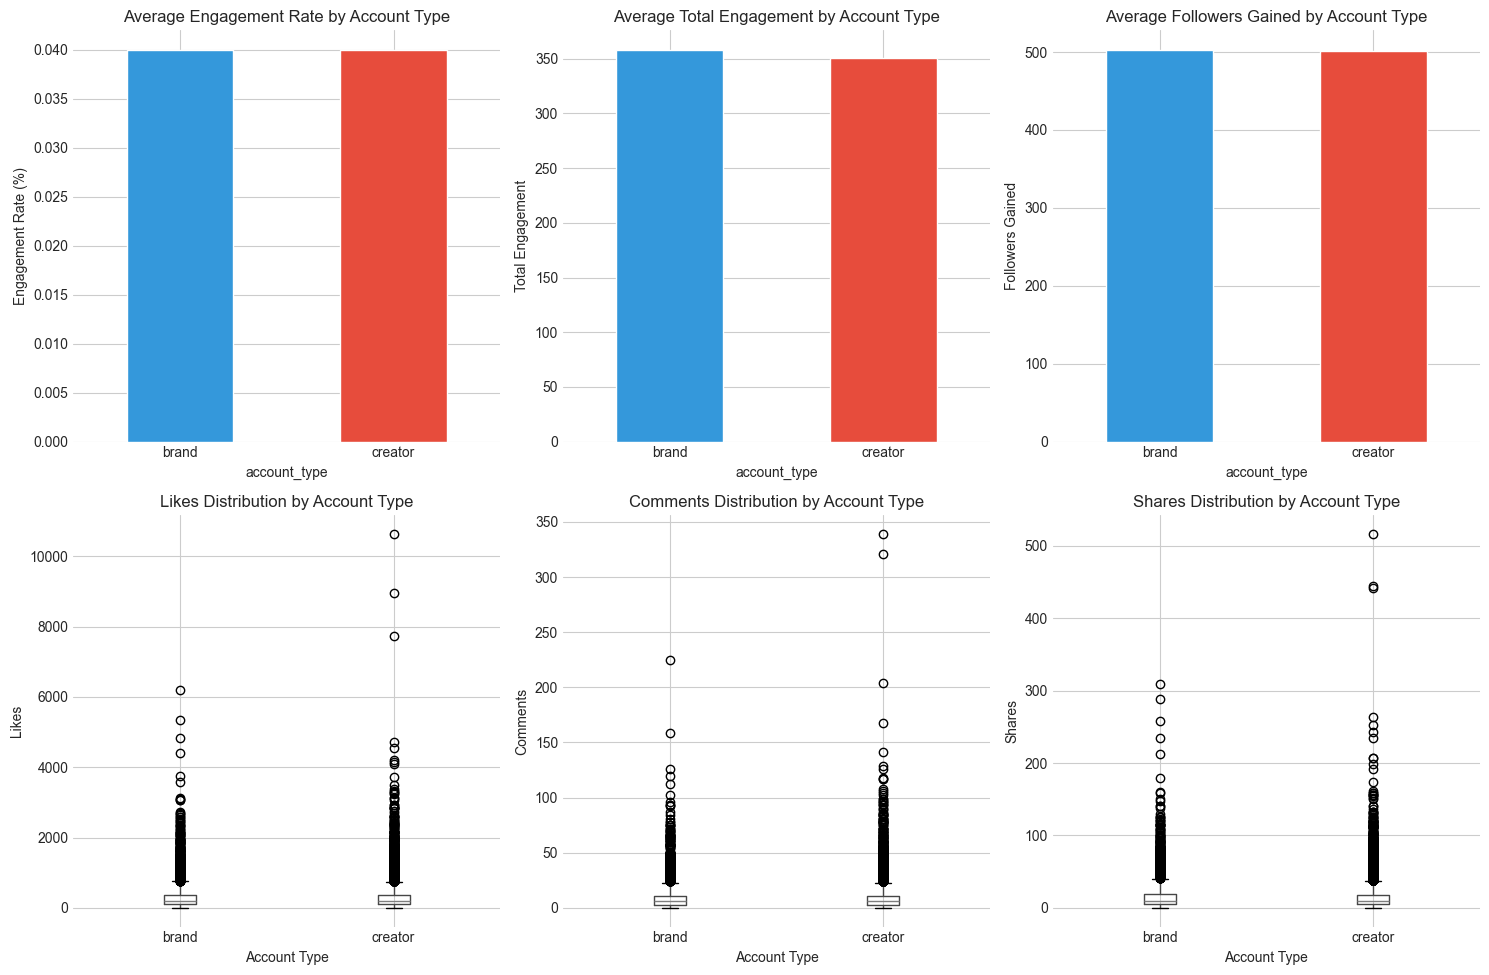


📊 Statistical Test (t-test):
t-statistic: -0.1555
p-value: 0.8764
ℹ️ No significant difference between brand and creator engagement rates.


In [8]:
"""
CELL 5: Account Type Performance Analysis
--------------------------------------
Purpose: Compare performance between brand and creator accounts
"""

print("📊 ACCOUNT TYPE ANALYSIS")
print("="*60)

# Group by account type
account_type_summary = df_clean.groupby('account_type').agg({
    'post_id': 'count',
    'engagement_rate': 'mean',
    'total_engagement': 'mean',
    'followers_gained': 'mean',
    'reach': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'saves': 'mean'
}).round(2)

account_type_summary.columns = ['Post Count', 'Avg Engagement Rate', 'Avg Total Engagement', 
                                'Avg Followers Gained', 'Avg Reach', 'Avg Likes', 
                                'Avg Comments', 'Avg Shares', 'Avg Saves']
print(account_type_summary)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Engagement Rate by Account Type
account_type_summary['Avg Engagement Rate'].plot(kind='bar', ax=axes[0,0], color=['#3498db', '#e74c3c'])
axes[0,0].set_title('Average Engagement Rate by Account Type')
axes[0,0].set_ylabel('Engagement Rate (%)')
axes[0,0].tick_params(axis='x', rotation=0)

# Total Engagement by Account Type
account_type_summary['Avg Total Engagement'].plot(kind='bar', ax=axes[0,1], color=['#3498db', '#e74c3c'])
axes[0,1].set_title('Average Total Engagement by Account Type')
axes[0,1].set_ylabel('Total Engagement')
axes[0,1].tick_params(axis='x', rotation=0)

# Followers Gained by Account Type
account_type_summary['Avg Followers Gained'].plot(kind='bar', ax=axes[0,2], color=['#3498db', '#e74c3c'])
axes[0,2].set_title('Average Followers Gained by Account Type')
axes[0,2].set_ylabel('Followers Gained')
axes[0,2].tick_params(axis='x', rotation=0)

# Likes Distribution
df_clean.boxplot(column='likes', by='account_type', ax=axes[1,0])
axes[1,0].set_title('Likes Distribution by Account Type')
axes[1,0].set_xlabel('Account Type')
axes[1,0].set_ylabel('Likes')

# Comments Distribution
df_clean.boxplot(column='comments', by='account_type', ax=axes[1,1])
axes[1,1].set_title('Comments Distribution by Account Type')
axes[1,1].set_xlabel('Account Type')
axes[1,1].set_ylabel('Comments')

# Shares Distribution
df_clean.boxplot(column='shares', by='account_type', ax=axes[1,2])
axes[1,2].set_title('Shares Distribution by Account Type')
axes[1,2].set_xlabel('Account Type')
axes[1,2].set_ylabel('Shares')

plt.suptitle('')
plt.tight_layout()
plt.savefig('account_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test (t-test)
brand_engagement = df_clean[df_clean['account_type'] == 'brand']['engagement_rate']
creator_engagement = df_clean[df_clean['account_type'] == 'creator']['engagement_rate']
t_stat, p_value = stats.ttest_ind(brand_engagement, creator_engagement)

print(f"\n📊 Statistical Test (t-test):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Significant difference between brand and creator engagement rates!")
else:
    print("ℹ️ No significant difference between brand and creator engagement rates.")

🎬 MEDIA TYPE ANALYSIS
            Post Count  Avg Engagement Rate  Avg Total Engagement  \
media_type                                                          
carousel         10627                 0.04                351.86   
image            11927                 0.04                355.53   
reel              7445                 0.04                351.06   

            Avg Followers Gained  Avg Reach  Avg Likes  Avg Comments  \
media_type                                                             
carousel                  506.86    6329.10     286.58          8.50   
image                     500.91    6268.62     289.73          8.55   
reel                      497.42    6197.83     285.86          8.51   

            Avg Shares  Avg Saves  
media_type                         
carousel         14.33      42.44  
image            14.57      42.69  
reel             14.33      42.35  


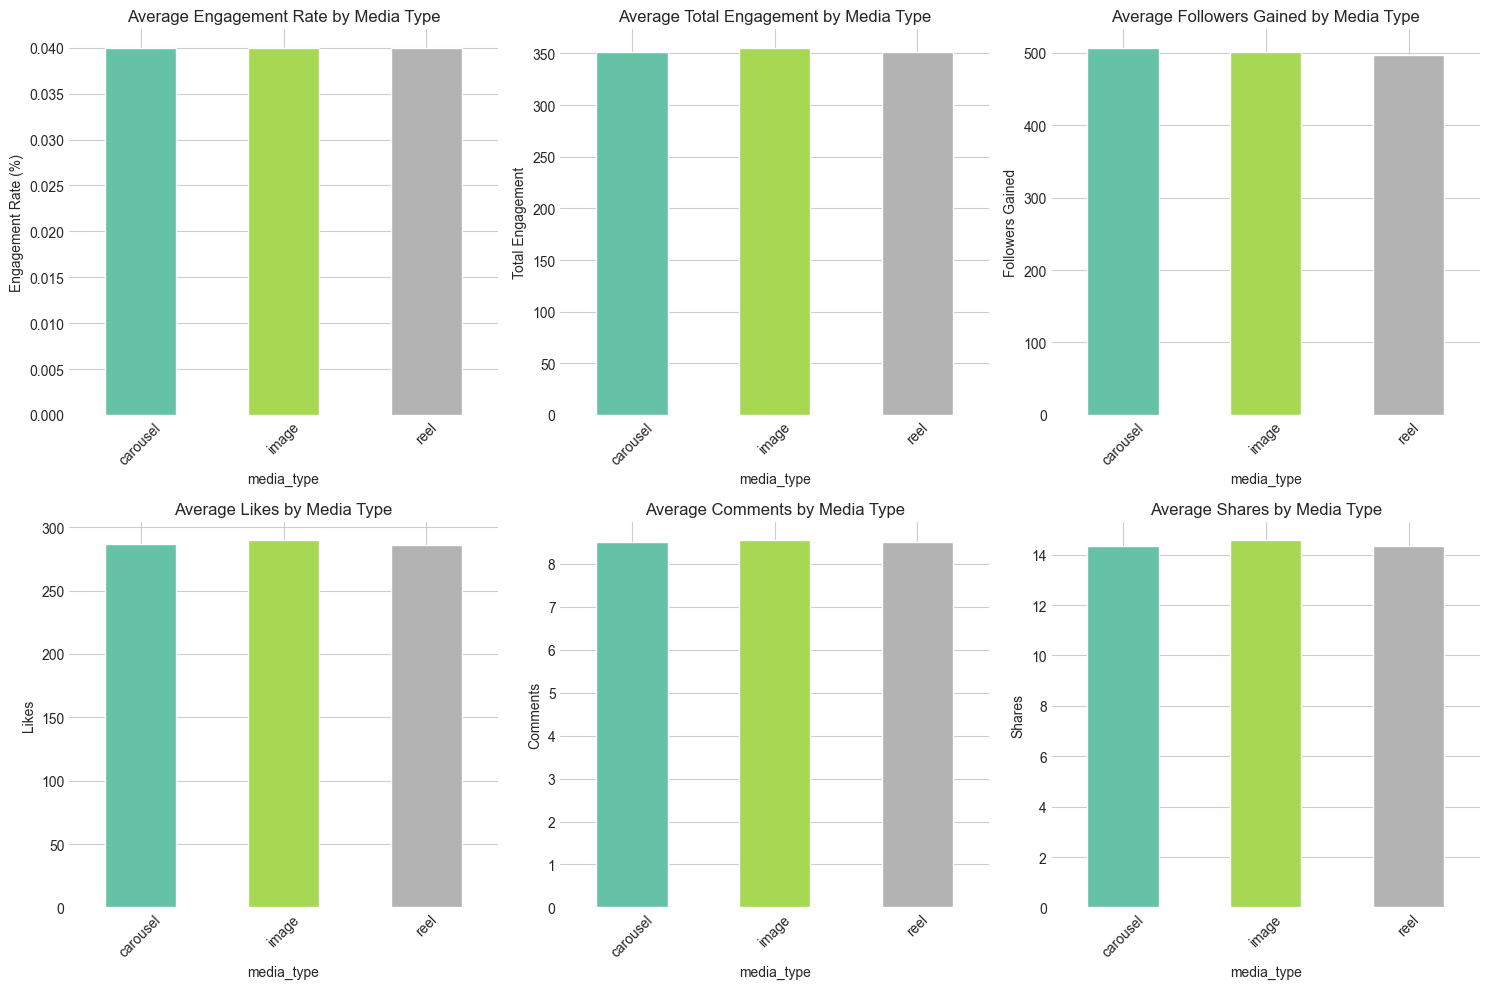


🏆 Best performing media type: carousel
   Engagement Rate: 0.04%


In [9]:
"""
CELL 6: Media Type Performance Analysis
------------------------------------
Purpose: Compare performance across different media types (image, reel, carousel)
"""

print("🎬 MEDIA TYPE ANALYSIS")
print("="*60)

# Group by media type
media_type_summary = df_clean.groupby('media_type').agg({
    'post_id': 'count',
    'engagement_rate': 'mean',
    'total_engagement': 'mean',
    'followers_gained': 'mean',
    'reach': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'saves': 'mean'
}).round(2)

media_type_summary.columns = ['Post Count', 'Avg Engagement Rate', 'Avg Total Engagement', 
                              'Avg Followers Gained', 'Avg Reach', 'Avg Likes', 
                              'Avg Comments', 'Avg Shares', 'Avg Saves']
print(media_type_summary)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors = plt.cm.Set2(np.linspace(0, 1, len(media_type_summary)))

# Engagement Rate by Media Type
media_type_summary['Avg Engagement Rate'].plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('Average Engagement Rate by Media Type')
axes[0,0].set_ylabel('Engagement Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# Total Engagement by Media Type
media_type_summary['Avg Total Engagement'].plot(kind='bar', ax=axes[0,1], color=colors)
axes[0,1].set_title('Average Total Engagement by Media Type')
axes[0,1].set_ylabel('Total Engagement')
axes[0,1].tick_params(axis='x', rotation=45)

# Followers Gained by Media Type
media_type_summary['Avg Followers Gained'].plot(kind='bar', ax=axes[0,2], color=colors)
axes[0,2].set_title('Average Followers Gained by Media Type')
axes[0,2].set_ylabel('Followers Gained')
axes[0,2].tick_params(axis='x', rotation=45)

# Likes by Media Type
media_type_summary['Avg Likes'].plot(kind='bar', ax=axes[1,0], color=colors)
axes[1,0].set_title('Average Likes by Media Type')
axes[1,0].set_ylabel('Likes')
axes[1,0].tick_params(axis='x', rotation=45)

# Comments by Media Type
media_type_summary['Avg Comments'].plot(kind='bar', ax=axes[1,1], color=colors)
axes[1,1].set_title('Average Comments by Media Type')
axes[1,1].set_ylabel('Comments')
axes[1,1].tick_params(axis='x', rotation=45)

# Shares by Media Type
media_type_summary['Avg Shares'].plot(kind='bar', ax=axes[1,2], color=colors)
axes[1,2].set_title('Average Shares by Media Type')
axes[1,2].set_ylabel('Shares')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('media_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Best performing media type
best_media = media_type_summary['Avg Engagement Rate'].idxmax()
print(f"\n🏆 Best performing media type: {best_media}")
print(f"   Engagement Rate: {media_type_summary.loc[best_media, 'Avg Engagement Rate']:.2f}%")

📑 CONTENT CATEGORY ANALYSIS
                  Post Count  Avg Engagement  Median Engagement  \
content_category                                                  
Beauty                  2953            0.04               0.04   
Comedy                  2950            0.04               0.04   
Fashion                 3034            0.04               0.04   
Fitness                 3004            0.04               0.04   
Food                    3010            0.04               0.04   
Lifestyle               3017            0.04               0.04   
Music                   3003            0.04               0.04   
Photography             3035            0.04               0.04   
Technology              3025            0.04               0.04   
Travel                  2968            0.04               0.04   

                  Std Engagement  Avg Total Engagement  Avg Followers Gained  \
content_category                                                               
Beauty 

C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\157740854.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(category_data, labels=top_5_categories)


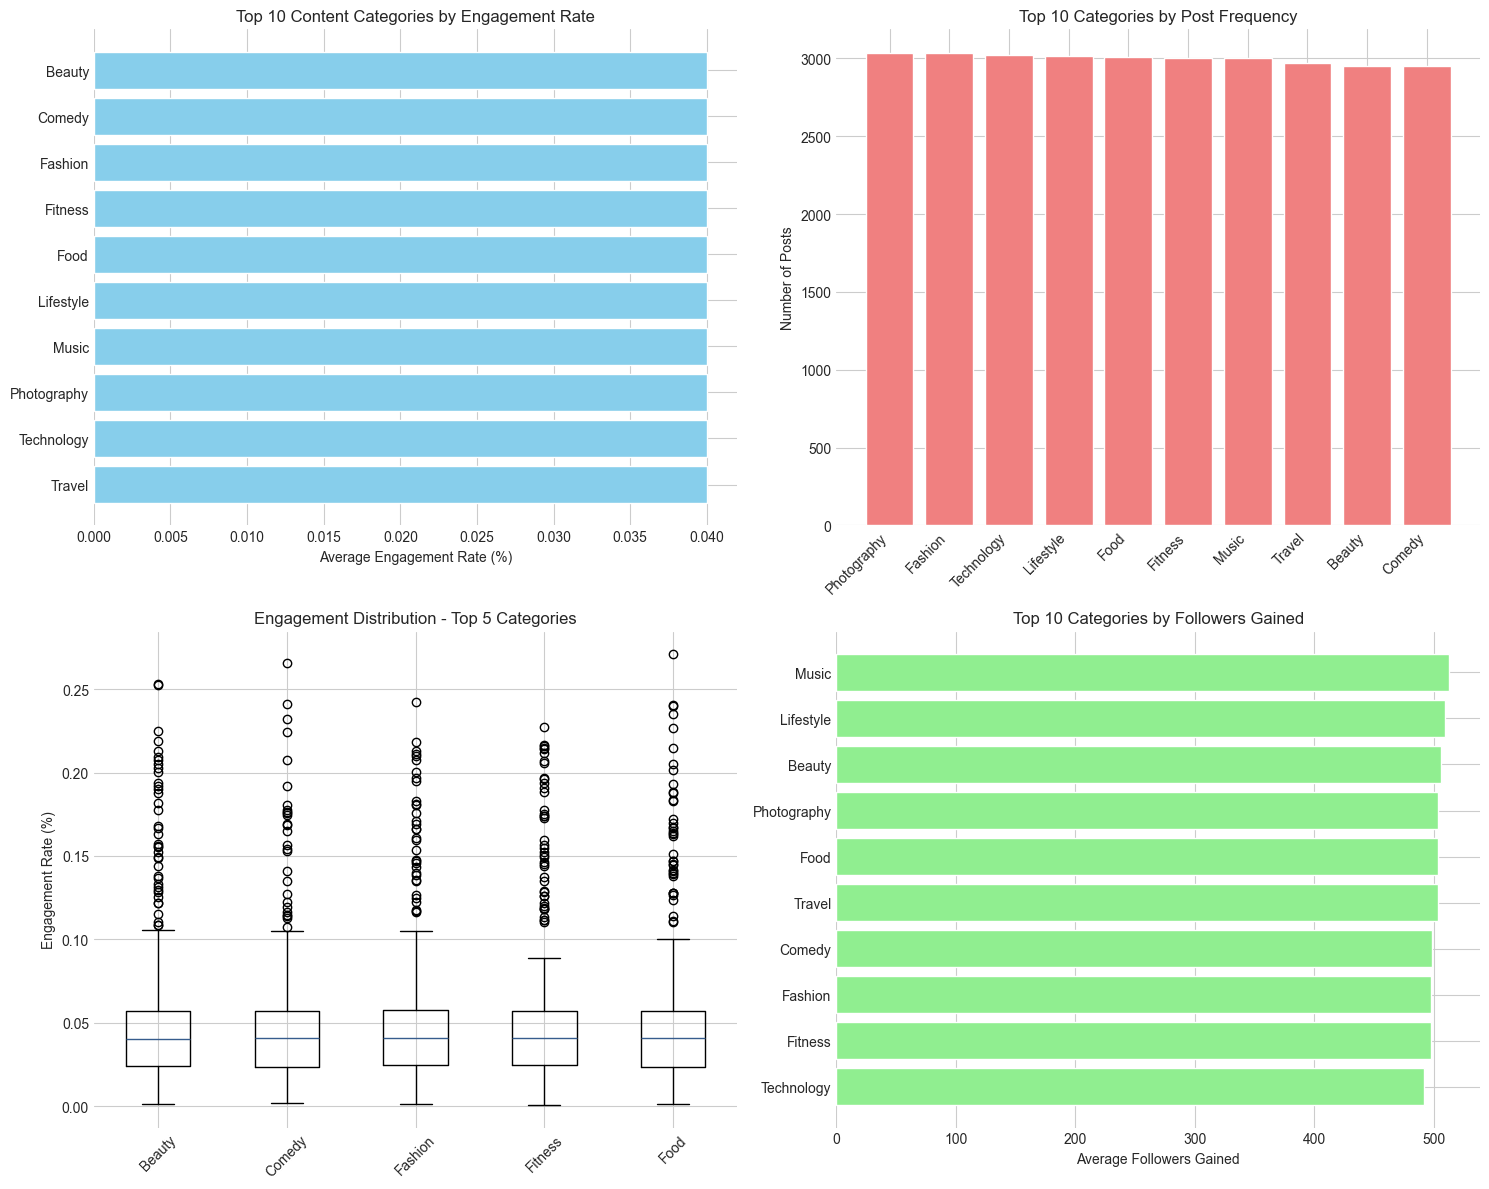


🏆 Best performing content category: Beauty
   Engagement Rate: 0.04%
   Posts: 2953.0


In [10]:
"""
CELL 7: Content Category Performance Analysis
------------------------------------------
Purpose: Analyze which content categories perform best
"""

print("📑 CONTENT CATEGORY ANALYSIS")
print("="*60)

# Group by content category
content_summary = df_clean.groupby('content_category').agg({
    'post_id': 'count',
    'engagement_rate': ['mean', 'median', 'std'],
    'total_engagement': 'mean',
    'followers_gained': 'mean',
    'reach': 'mean'
}).round(2)

content_summary.columns = ['Post Count', 'Avg Engagement', 'Median Engagement', 
                          'Std Engagement', 'Avg Total Engagement', 
                          'Avg Followers Gained', 'Avg Reach']
content_summary = content_summary.sort_values('Avg Engagement', ascending=False)
print(content_summary)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Engagement Rate by Category
top_categories = content_summary.head(10)
axes[0,0].barh(range(len(top_categories)), top_categories['Avg Engagement'].values, color='skyblue')
axes[0,0].set_yticks(range(len(top_categories)))
axes[0,0].set_yticklabels(top_categories.index)
axes[0,0].set_xlabel('Average Engagement Rate (%)')
axes[0,0].set_title('Top 10 Content Categories by Engagement Rate')
axes[0,0].invert_yaxis()

# Post Count by Category
post_counts = df_clean['content_category'].value_counts().head(10)
axes[0,1].bar(range(len(post_counts)), post_counts.values, color='lightcoral')
axes[0,1].set_xticks(range(len(post_counts)))
axes[0,1].set_xticklabels(post_counts.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Number of Posts')
axes[0,1].set_title('Top 10 Categories by Post Frequency')

# Engagement Distribution by Category (Box Plot)
top_5_categories = content_summary.head(5).index.tolist()
category_data = [df_clean[df_clean['content_category'] == cat]['engagement_rate'].values 
                 for cat in top_5_categories]
axes[1,0].boxplot(category_data, labels=top_5_categories)
axes[1,0].set_ylabel('Engagement Rate (%)')
axes[1,0].set_title('Engagement Distribution - Top 5 Categories')
axes[1,0].tick_params(axis='x', rotation=45)

# Followers Gained by Category
top_followers = df_clean.groupby('content_category')['followers_gained'].mean().sort_values(ascending=False).head(10)
axes[1,1].barh(range(len(top_followers)), top_followers.values, color='lightgreen')
axes[1,1].set_yticks(range(len(top_followers)))
axes[1,1].set_yticklabels(top_followers.index)
axes[1,1].set_xlabel('Average Followers Gained')
axes[1,1].set_title('Top 10 Categories by Followers Gained')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('content_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Best performing category
best_category = content_summary.index[0]
print(f"\n🏆 Best performing content category: {best_category}")
print(f"   Engagement Rate: {content_summary.iloc[0]['Avg Engagement']:.2f}%")
print(f"   Posts: {content_summary.iloc[0]['Post Count']}")

🔄 TRAFFIC SOURCE ANALYSIS
                Post Count  Avg Engagement Rate  Avg Reach  Avg Impressions  \
traffic_source                                                                
Explore               4874                 0.04    6207.25          8379.61   
External              5005                 0.04    6381.32          8599.33   
Hashtags              5063                 0.04    6330.00          8566.88   
Home Feed             5069                 0.04    6192.50          8370.81   
Profile               4962                 0.04    6221.92          8385.87   
Reels Feed            5026                 0.04    6299.96          8496.18   

                Avg Followers Gained  
traffic_source                        
Explore                       502.75  
External                      502.77  
Hashtags                      492.17  
Home Feed                     502.54  
Profile                       511.14  
Reels Feed                    501.75  


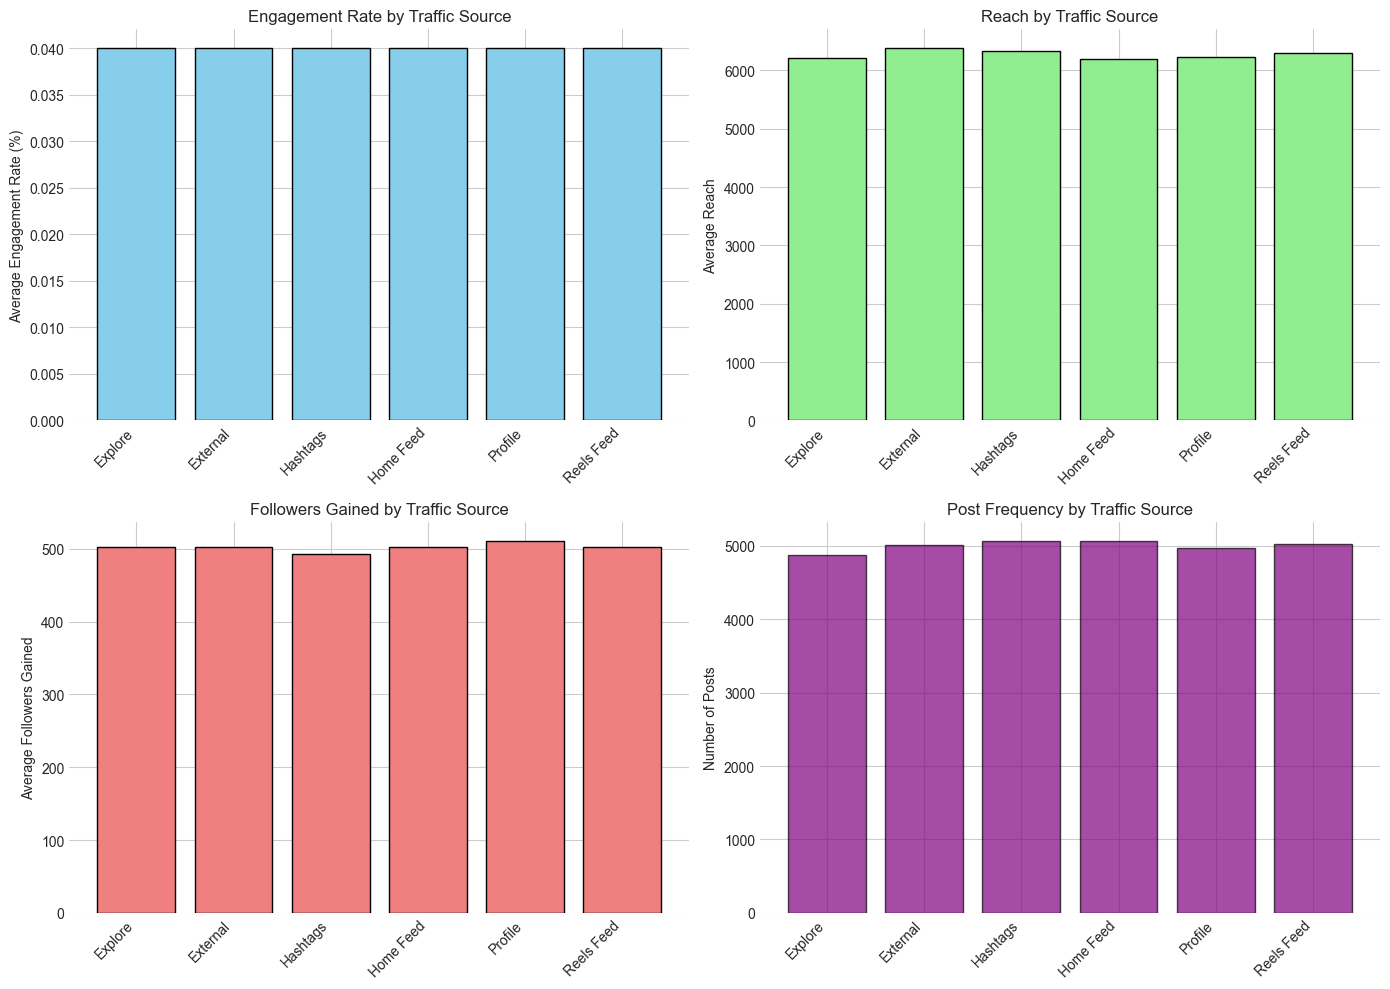


🏆 Best performing traffic source: Explore
   Engagement Rate: 0.04%


In [11]:
"""
CELL 8: Traffic Source Performance Analysis
----------------------------------------
Purpose: Analyze which traffic sources drive the best engagement
"""

print("🔄 TRAFFIC SOURCE ANALYSIS")
print("="*60)

# Group by traffic source
traffic_summary = df_clean.groupby('traffic_source').agg({
    'post_id': 'count',
    'engagement_rate': 'mean',
    'reach': 'mean',
    'impressions': 'mean',
    'followers_gained': 'mean'
}).round(2)

traffic_summary.columns = ['Post Count', 'Avg Engagement Rate', 'Avg Reach', 
                          'Avg Impressions', 'Avg Followers Gained']
traffic_summary = traffic_summary.sort_values('Avg Engagement Rate', ascending=False)
print(traffic_summary)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Engagement Rate by Traffic Source
axes[0,0].bar(range(len(traffic_summary)), traffic_summary['Avg Engagement Rate'].values, 
              color='skyblue', edgecolor='black')
axes[0,0].set_xticks(range(len(traffic_summary)))
axes[0,0].set_xticklabels(traffic_summary.index, rotation=45, ha='right')
axes[0,0].set_ylabel('Average Engagement Rate (%)')
axes[0,0].set_title('Engagement Rate by Traffic Source')

# Reach by Traffic Source
axes[0,1].bar(range(len(traffic_summary)), traffic_summary['Avg Reach'].values, 
              color='lightgreen', edgecolor='black')
axes[0,1].set_xticks(range(len(traffic_summary)))
axes[0,1].set_xticklabels(traffic_summary.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Average Reach')
axes[0,1].set_title('Reach by Traffic Source')

# Followers Gained by Traffic Source
axes[1,0].bar(range(len(traffic_summary)), traffic_summary['Avg Followers Gained'].values, 
              color='lightcoral', edgecolor='black')
axes[1,0].set_xticks(range(len(traffic_summary)))
axes[1,0].set_xticklabels(traffic_summary.index, rotation=45, ha='right')
axes[1,0].set_ylabel('Average Followers Gained')
axes[1,0].set_title('Followers Gained by Traffic Source')

# Post Count by Traffic Source
axes[1,1].bar(range(len(traffic_summary)), traffic_summary['Post Count'].values, 
              color='purple', alpha=0.7, edgecolor='black')
axes[1,1].set_xticks(range(len(traffic_summary)))
axes[1,1].set_xticklabels(traffic_summary.index, rotation=45, ha='right')
axes[1,1].set_ylabel('Number of Posts')
axes[1,1].set_title('Post Frequency by Traffic Source')

plt.tight_layout()
plt.savefig('traffic_source_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Best performing traffic source
best_traffic = traffic_summary.index[0]
print(f"\n🏆 Best performing traffic source: {best_traffic}")
print(f"   Engagement Rate: {traffic_summary.iloc[0]['Avg Engagement Rate']:.2f}%")

📢 CALL-TO-ACTION ANALYSIS
                    Post Count  Avg Engagement  Median Engagement  \
has_call_to_action                                                  
0                        19536            0.04               0.04   
1                        10463            0.04               0.04   

                    Avg Total Engagement  Avg Followers Gained  Avg Likes  \
has_call_to_action                                                          
0                                 353.68                501.84     288.17   
1                                 352.08                502.74     286.70   

                    Avg Comments  Avg Shares  Avg Saves  
has_call_to_action                                       
0                           8.51       14.45      42.54  
1                           8.54       14.38      42.47  


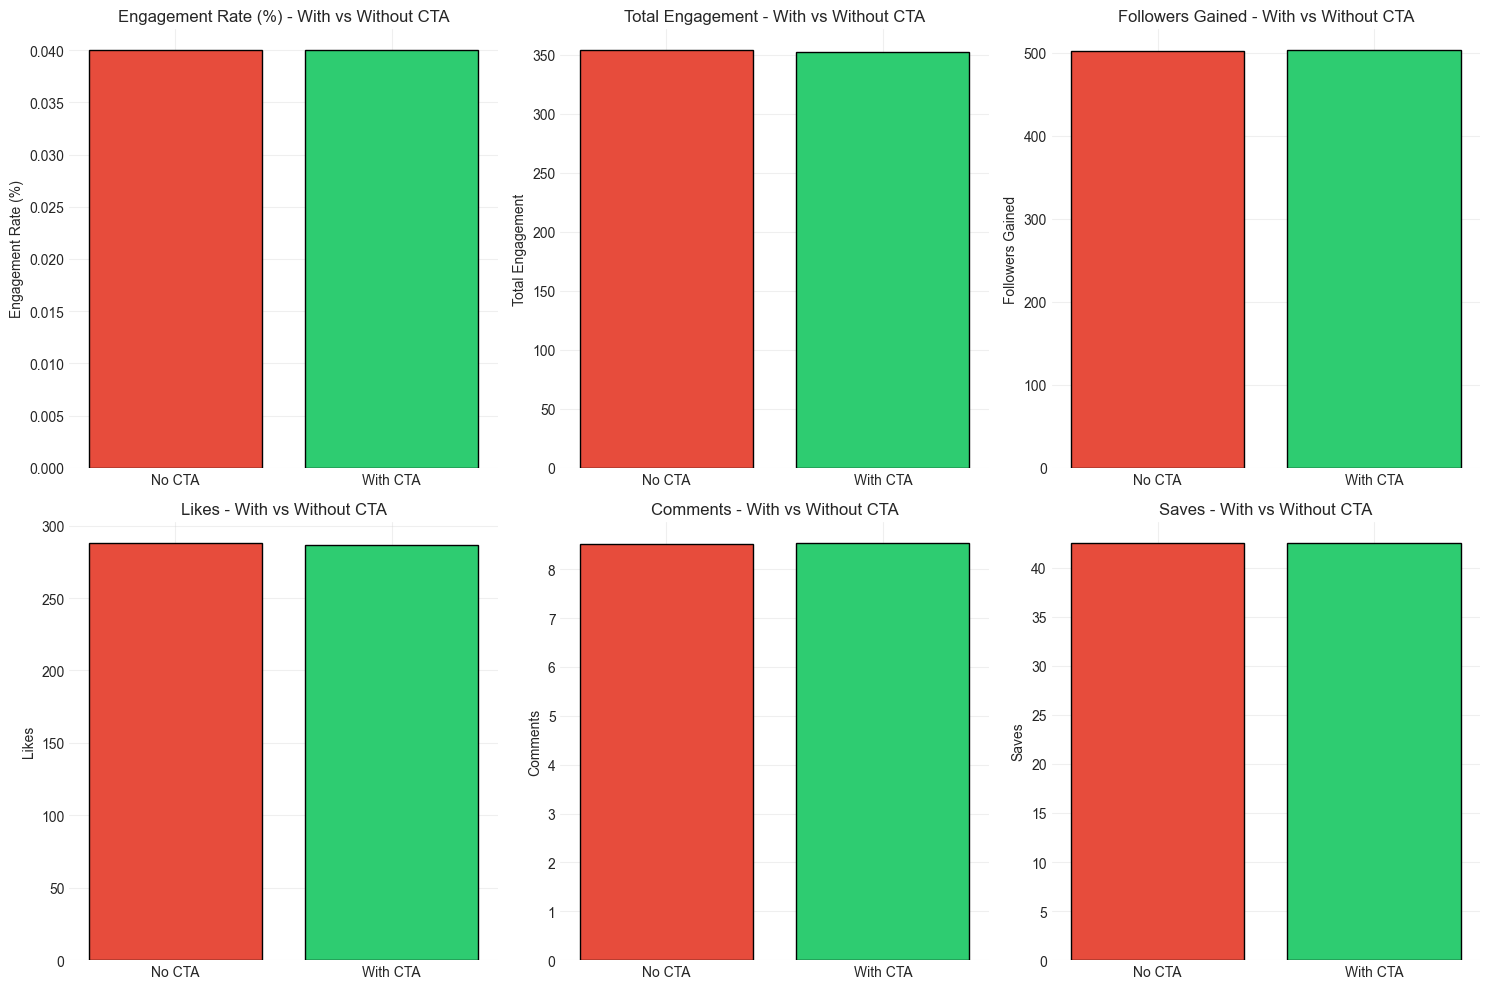


📊 Statistical Test (t-test):
t-statistic: -1.2200
p-value: 0.2225
ℹ️ No significant impact from CTA on engagement.


In [12]:
"""
CELL 9: Call-to-Action Impact Analysis
-----------------------------------
Purpose: Analyze the impact of having a call-to-action on engagement
"""

print("📢 CALL-TO-ACTION ANALYSIS")
print("="*60)

# Group by has_call_to_action
cta_summary = df_clean.groupby('has_call_to_action').agg({
    'post_id': 'count',
    'engagement_rate': ['mean', 'median'],
    'total_engagement': 'mean',
    'followers_gained': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'saves': 'mean'
}).round(2)

cta_summary.columns = ['Post Count', 'Avg Engagement', 'Median Engagement', 
                       'Avg Total Engagement', 'Avg Followers Gained',
                       'Avg Likes', 'Avg Comments', 'Avg Shares', 'Avg Saves']
print(cta_summary)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics = ['Avg Engagement', 'Avg Total Engagement', 'Avg Followers Gained',
           'Avg Likes', 'Avg Comments', 'Avg Saves']
titles = ['Engagement Rate (%)', 'Total Engagement', 'Followers Gained',
          'Likes', 'Comments', 'Saves']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 3
    col = idx % 3
    values = [cta_summary.loc[0, metric] if 0 in cta_summary.index else 0,
              cta_summary.loc[1, metric] if 1 in cta_summary.index else 0]
    axes[row, col].bar(['No CTA', 'With CTA'], values, 
                       color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[row, col].set_ylabel(title)
    axes[row, col].set_title(f'{title} - With vs Without CTA')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cta_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
cta_yes = df_clean[df_clean['has_call_to_action'] == 1]['engagement_rate']
cta_no = df_clean[df_clean['has_call_to_action'] == 0]['engagement_rate']
t_stat, p_value = stats.ttest_ind(cta_yes, cta_no)

print(f"\n📊 Statistical Test (t-test):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    improvement = ((cta_yes.mean() - cta_no.mean()) / cta_no.mean()) * 100
    print(f"✅ CTA improves engagement by {improvement:.1f}%!")
else:
    print("ℹ️ No significant impact from CTA on engagement.")

⏰ TIMING ANALYSIS

📅 PERFORMANCE BY DAY OF WEEK:
             Avg Engagement  Median Engagement  Post Count  \
day_of_week                                                  
Monday                 0.04               0.04        4279   
Tuesday                0.04               0.04        4351   
Wednesday              0.04               0.04        4341   
Thursday               0.04               0.04        4351   
Friday                 0.04               0.04        4218   
Saturday               0.04               0.04        4254   
Sunday                 0.04               0.04        4205   

             Avg Total Engagement  Avg Followers Gained  
day_of_week                                              
Monday                     355.55                495.79  
Tuesday                    360.57                494.87  
Wednesday                  344.32                501.91  
Thursday                   348.98                505.13  
Friday                     356.99           

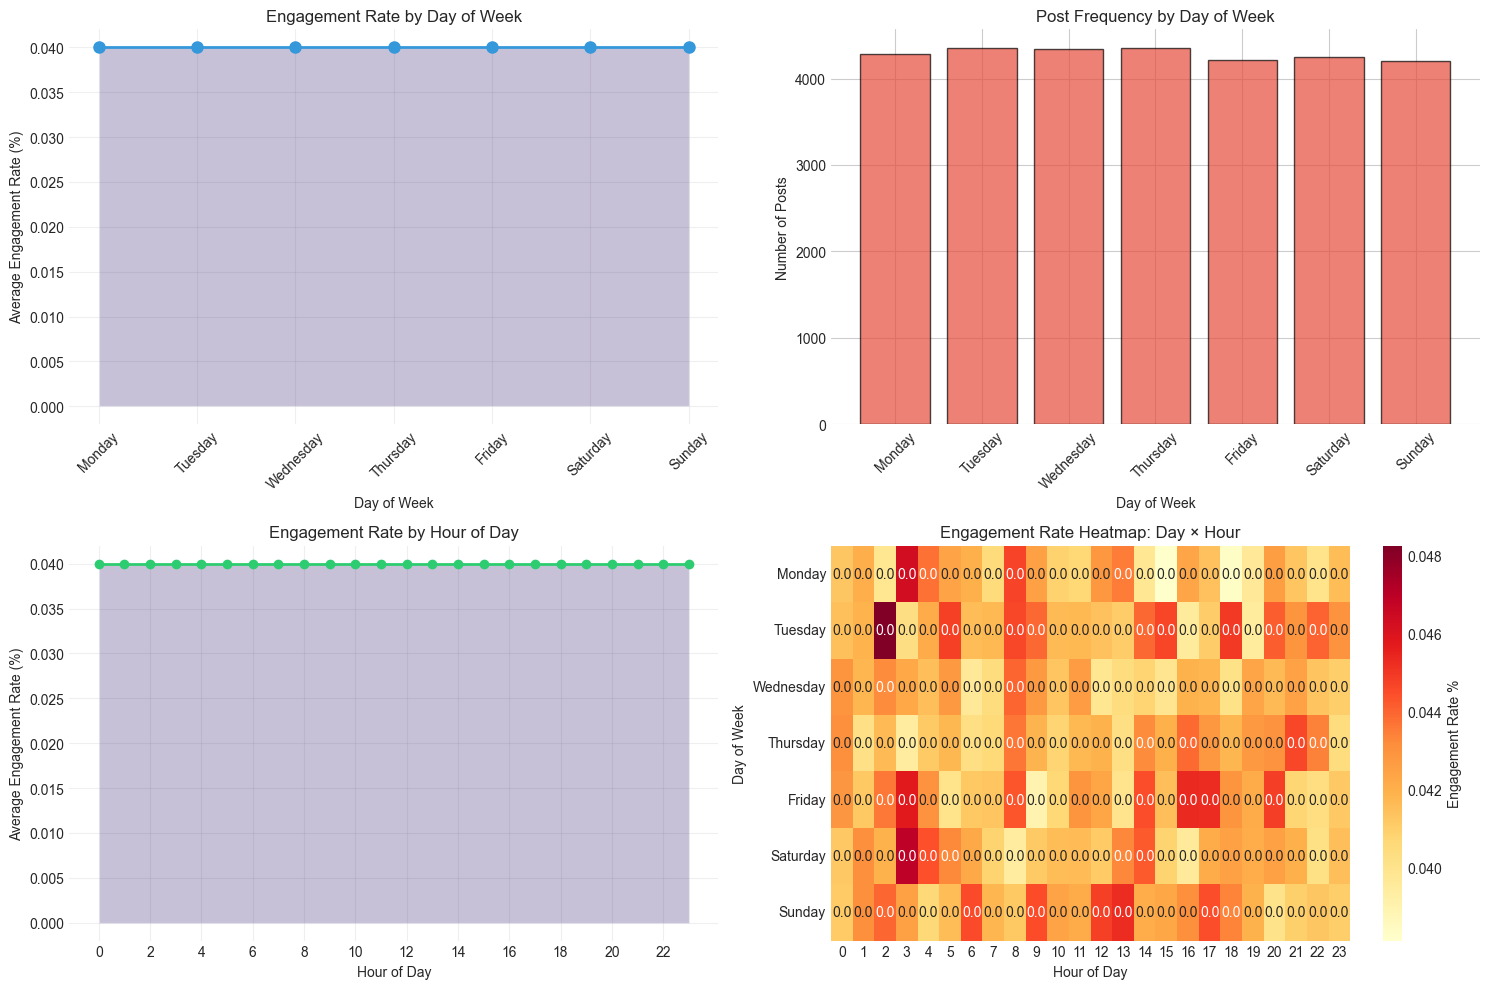


🏆 Best day to post: Monday
   Engagement Rate: 0.04%

🏆 Best hour to post: 0:00
   Engagement Rate: 0.04%

📊 Weekend vs Weekday:
   Weekend engagement: 0.04%
   Weekday engagement: 0.04%
   Difference: 0.6%


In [13]:
"""
CELL 10: Timing Analysis - Best Posting Times
------------------------------------------
Purpose: Identify optimal posting days and hours for maximum engagement
"""

print("⏰ TIMING ANALYSIS")
print("="*60)

# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_summary = df_clean.groupby('day_of_week').agg({
    'engagement_rate': ['mean', 'median', 'count'],
    'total_engagement': 'mean',
    'followers_gained': 'mean'
}).round(2)

day_summary.columns = ['Avg Engagement', 'Median Engagement', 'Post Count', 
                       'Avg Total Engagement', 'Avg Followers Gained']
day_summary = day_summary.reindex(day_order)
print("\n📅 PERFORMANCE BY DAY OF WEEK:")
print(day_summary)

# Hour analysis
hour_summary = df_clean.groupby('post_hour').agg({
    'engagement_rate': ['mean', 'median', 'count'],
    'total_engagement': 'mean'
}).round(2)

hour_summary.columns = ['Avg Engagement', 'Median Engagement', 'Post Count', 'Avg Total Engagement']
hour_summary = hour_summary.sort_index()
print("\n⏱️ PERFORMANCE BY HOUR:")
print(hour_summary)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Engagement by Day
axes[0,0].plot(day_summary.index, day_summary['Avg Engagement'].values, 
               marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0,0].fill_between(day_summary.index, day_summary['Avg Engagement'].values, alpha=0.3)
axes[0,0].set_xlabel('Day of Week')
axes[0,0].set_ylabel('Average Engagement Rate (%)')
axes[0,0].set_title('Engagement Rate by Day of Week')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Post Count by Day
axes[0,1].bar(day_summary.index, day_summary['Post Count'].values, 
              color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].set_ylabel('Number of Posts')
axes[0,1].set_title('Post Frequency by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)

# Engagement by Hour
axes[1,0].plot(hour_summary.index, hour_summary['Avg Engagement'].values, 
               marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1,0].fill_between(hour_summary.index, hour_summary['Avg Engagement'].values, alpha=0.3)
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Average Engagement Rate (%)')
axes[1,0].set_title('Engagement Rate by Hour of Day')
axes[1,0].set_xticks(range(0, 24, 2))
axes[1,0].grid(True, alpha=0.3)

# Heatmap of Day and Hour
pivot_table = df_clean.pivot_table(values='engagement_rate', 
                                    index='day_of_week', 
                                    columns='post_hour', 
                                    aggfunc='mean')
pivot_table = pivot_table.reindex(day_order)
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1], 
            cbar_kws={'label': 'Engagement Rate %'})
axes[1,1].set_title('Engagement Rate Heatmap: Day × Hour')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('timing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Best posting times
best_day = day_summary['Avg Engagement'].idxmax()
best_hour = hour_summary['Avg Engagement'].idxmax()
print(f"\n🏆 Best day to post: {best_day}")
print(f"   Engagement Rate: {day_summary.loc[best_day, 'Avg Engagement']:.2f}%")
print(f"\n🏆 Best hour to post: {best_hour}:00")
print(f"   Engagement Rate: {hour_summary.loc[best_hour, 'Avg Engagement']:.2f}%")

# Weekend vs Weekday
weekend_engagement = df_clean[df_clean['is_weekend'] == True]['engagement_rate'].mean()
weekday_engagement = df_clean[df_clean['is_weekend'] == False]['engagement_rate'].mean()
print(f"\n📊 Weekend vs Weekday:")
print(f"   Weekend engagement: {weekend_engagement:.2f}%")
print(f"   Weekday engagement: {weekday_engagement:.2f}%")
print(f"   Difference: {((weekend_engagement - weekday_engagement) / weekday_engagement) * 100:.1f}%")

#️⃣ HASHTAGS AND CAPTION ANALYSIS

📊 PERFORMANCE BY HASHTAG COUNT:
               Avg Engagement  Median Engagement  Post Count  Avg Reach
hashtag_group                                                          
0-3                      0.04               0.04        1303    6272.14
4-6                      0.04               0.04        8142    6299.29
7-10                     0.04               0.04       15053    6261.72
11-20                    0.04               0.04        5490    6265.77
21+                      0.09               0.09           1    2844.00

📝 PERFORMANCE BY CAPTION LENGTH:
                  Avg Engagement  Median Engagement  Post Count  Avg Reach
caption_group                                                             
Very Short (<50)             NaN                NaN           0        NaN
Short (50-100)              0.04               0.04        1069    6302.25
Medium (100-150)            0.04               0.04       28815    6270.43
Long (150-200)      

C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\2176344434.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hashtag_summary = df_clean.groupby('hashtag_group').agg({
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\2176344434.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  caption_summary = df_clean.groupby('caption_group').agg({


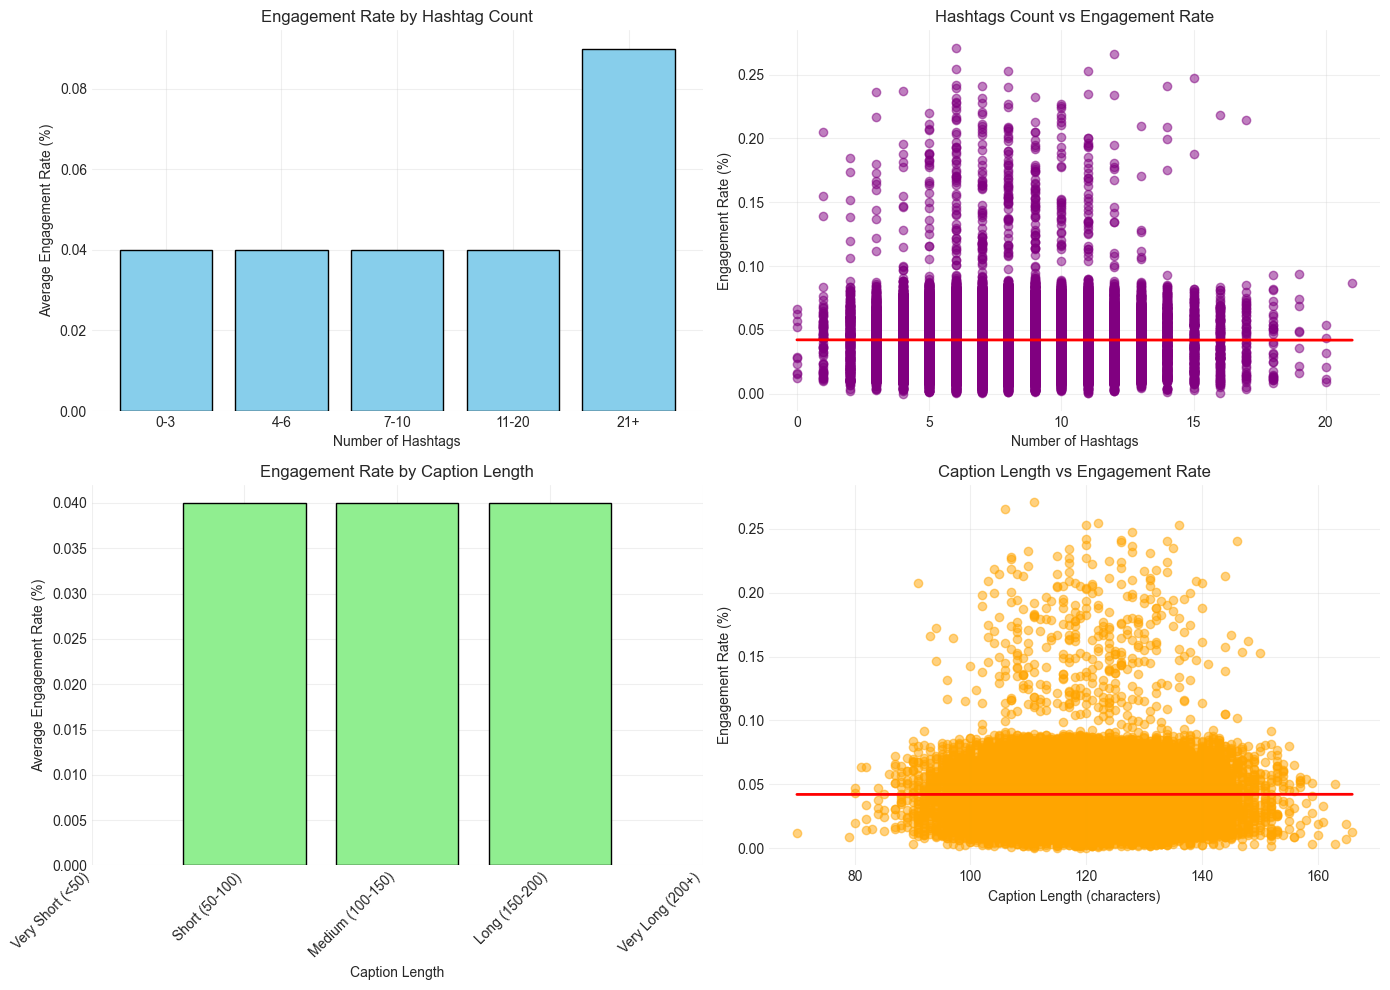


📊 Correlation Analysis:
Hashtags count vs Engagement: -0.001
Caption length vs Engagement: 0.000

🏆 Optimal hashtag count: 21+
   Engagement Rate: 0.09%

🏆 Optimal caption length: Short (50-100)
   Engagement Rate: 0.04%


In [14]:
"""
CELL 11: Hashtags and Caption Analysis
-----------------------------------
Purpose: Analyze the impact of hashtags and caption length on engagement
"""

print("#️⃣ HASHTAGS AND CAPTION ANALYSIS")
print("="*60)

# Hashtags count analysis
df_clean['hashtag_group'] = pd.cut(df_clean['hashtags_count'], 
                                    bins=[0, 3, 6, 10, 20, 50],
                                    labels=['0-3', '4-6', '7-10', '11-20', '21+'])

hashtag_summary = df_clean.groupby('hashtag_group').agg({
    'engagement_rate': ['mean', 'median', 'count'],
    'reach': 'mean'
}).round(2)

hashtag_summary.columns = ['Avg Engagement', 'Median Engagement', 'Post Count', 'Avg Reach']
print("\n📊 PERFORMANCE BY HASHTAG COUNT:")
print(hashtag_summary)

# Caption length analysis
df_clean['caption_group'] = pd.cut(df_clean['caption_length'],
                                    bins=[0, 50, 100, 150, 200, 1000],
                                    labels=['Very Short (<50)', 'Short (50-100)', 
                                            'Medium (100-150)', 'Long (150-200)', 'Very Long (200+)'])

caption_summary = df_clean.groupby('caption_group').agg({
    'engagement_rate': ['mean', 'median', 'count'],
    'reach': 'mean'
}).round(2)

caption_summary.columns = ['Avg Engagement', 'Median Engagement', 'Post Count', 'Avg Reach']
print("\n📝 PERFORMANCE BY CAPTION LENGTH:")
print(caption_summary)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Engagement by Hashtag Count
axes[0,0].bar(range(len(hashtag_summary)), hashtag_summary['Avg Engagement'].values, 
              color='skyblue', edgecolor='black')
axes[0,0].set_xticks(range(len(hashtag_summary)))
axes[0,0].set_xticklabels(hashtag_summary.index)
axes[0,0].set_xlabel('Number of Hashtags')
axes[0,0].set_ylabel('Average Engagement Rate (%)')
axes[0,0].set_title('Engagement Rate by Hashtag Count')
axes[0,0].grid(True, alpha=0.3)

# Scatter plot - Hashtags vs Engagement
axes[0,1].scatter(df_clean['hashtags_count'], df_clean['engagement_rate'], 
                  alpha=0.5, color='purple')
z = np.polyfit(df_clean['hashtags_count'].dropna(), 
               df_clean['engagement_rate'].dropna(), 1)
p = np.poly1d(z)
axes[0,1].plot(df_clean['hashtags_count'].sort_values(), 
               p(df_clean['hashtags_count'].sort_values()), 
               color='red', linewidth=2)
axes[0,1].set_xlabel('Number of Hashtags')
axes[0,1].set_ylabel('Engagement Rate (%)')
axes[0,1].set_title('Hashtags Count vs Engagement Rate')
axes[0,1].grid(True, alpha=0.3)

# Engagement by Caption Length
axes[1,0].bar(range(len(caption_summary)), caption_summary['Avg Engagement'].values, 
              color='lightgreen', edgecolor='black')
axes[1,0].set_xticks(range(len(caption_summary)))
axes[1,0].set_xticklabels(caption_summary.index, rotation=45, ha='right')
axes[1,0].set_xlabel('Caption Length')
axes[1,0].set_ylabel('Average Engagement Rate (%)')
axes[1,0].set_title('Engagement Rate by Caption Length')
axes[1,0].grid(True, alpha=0.3)

# Scatter plot - Caption Length vs Engagement
axes[1,1].scatter(df_clean['caption_length'], df_clean['engagement_rate'], 
                  alpha=0.5, color='orange')
z = np.polyfit(df_clean['caption_length'].dropna(), 
               df_clean['engagement_rate'].dropna(), 1)
p = np.poly1d(z)
axes[1,1].plot(df_clean['caption_length'].sort_values(), 
               p(df_clean['caption_length'].sort_values()), 
               color='red', linewidth=2)
axes[1,1].set_xlabel('Caption Length (characters)')
axes[1,1].set_ylabel('Engagement Rate (%)')
axes[1,1].set_title('Caption Length vs Engagement Rate')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hashtags_caption_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation analysis
corr_hashtags = df_clean['hashtags_count'].corr(df_clean['engagement_rate'])
corr_caption = df_clean['caption_length'].corr(df_clean['engagement_rate'])

print(f"\n📊 Correlation Analysis:")
print(f"Hashtags count vs Engagement: {corr_hashtags:.3f}")
print(f"Caption length vs Engagement: {corr_caption:.3f}")

# Optimal ranges
best_hashtag_group = hashtag_summary['Avg Engagement'].idxmax()
best_caption_group = caption_summary['Avg Engagement'].idxmax()
print(f"\n🏆 Optimal hashtag count: {best_hashtag_group}")
print(f"   Engagement Rate: {hashtag_summary.loc[best_hashtag_group, 'Avg Engagement']:.2f}%")
print(f"\n🏆 Optimal caption length: {best_caption_group}")
print(f"   Engagement Rate: {caption_summary.loc[best_caption_group, 'Avg Engagement']:.2f}%")

📈 FOLLOWER SIZE IMPACT ANALYSIS

📊 PERFORMANCE BY FOLLOWER TIER:
                 Avg Engagement  Median Engagement  Std Engagement  \
follower_tier                                                        
Micro (<5k)                0.04               0.04            0.03   
Small (5-15k)              0.04               0.04            0.02   
Medium (15-50k)            0.04               0.04            0.02   
Large (>50k)                NaN                NaN             NaN   

                 Avg Reach Rate  Avg Followers Gained  Post Count  
follower_tier                                                      
Micro (<5k)              165.53                497.34        7465  
Small (5-15k)             71.56                501.94       16546  
Medium (15-50k)           32.05                508.75        5988  
Large (>50k)                NaN                   NaN           0  


C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\915123250.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  follower_summary = df_clean.groupby('follower_tier').agg({


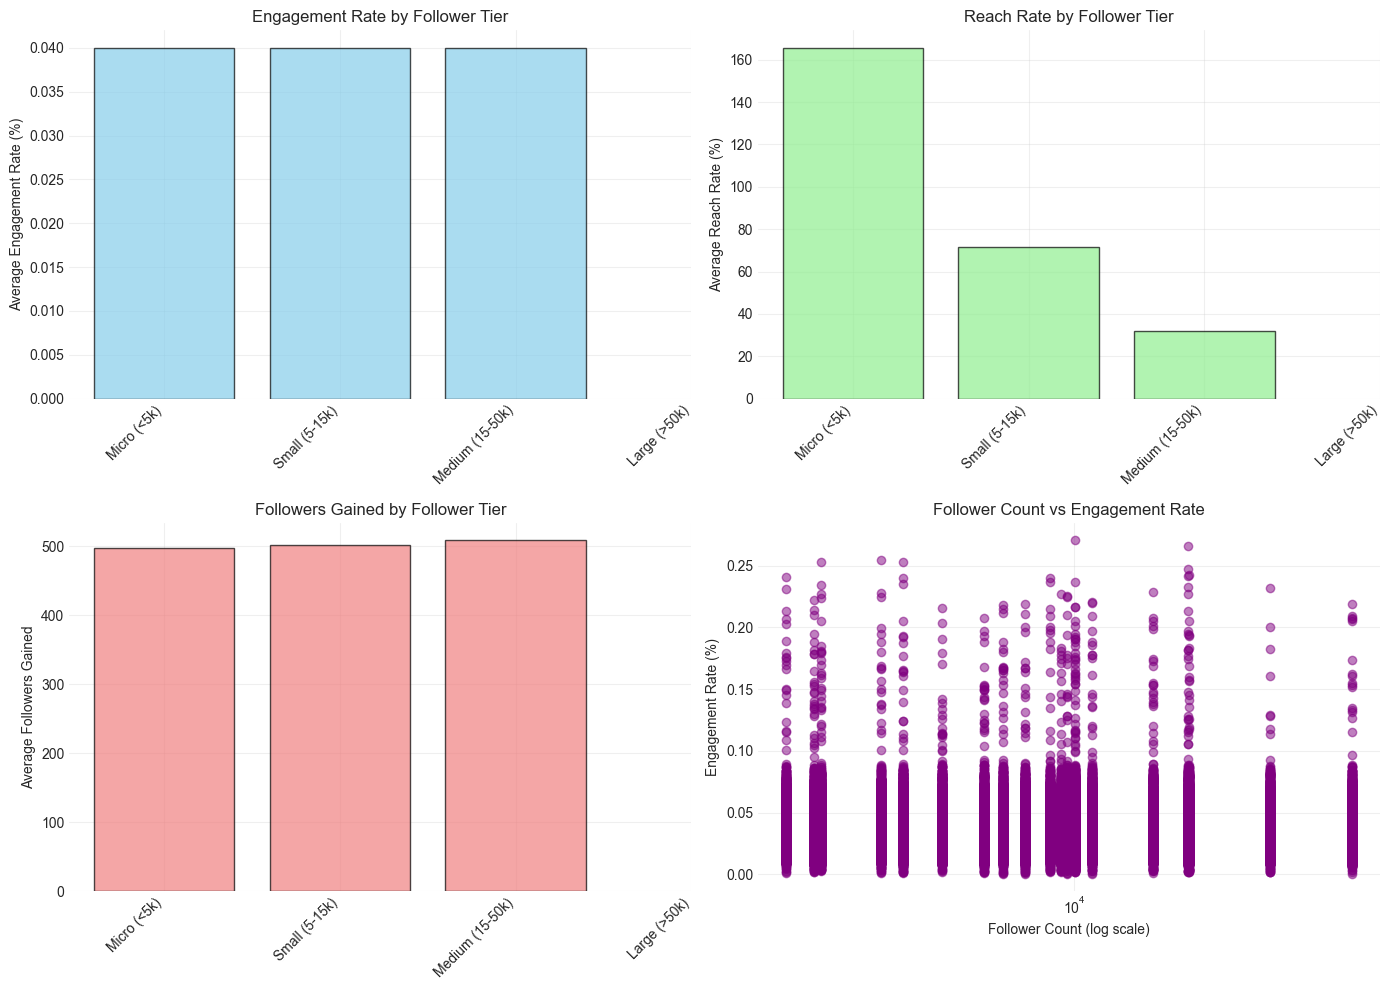


📊 Correlation between follower count and engagement rate: -0.006

🏆 Best performing follower tier: Micro (<5k)
   Engagement Rate: 0.04%


In [15]:
"""
CELL 12: Follower Size Impact Analysis
-----------------------------------
Purpose: Analyze how follower count affects engagement metrics
"""

print("📈 FOLLOWER SIZE IMPACT ANALYSIS")
print("="*60)

# Follower tier summary
follower_summary = df_clean.groupby('follower_tier').agg({
    'engagement_rate': ['mean', 'median', 'std'],
    'reach_rate': 'mean',
    'followers_gained': 'mean',
    'post_id': 'count'
}).round(2)

follower_summary.columns = ['Avg Engagement', 'Median Engagement', 'Std Engagement',
                           'Avg Reach Rate', 'Avg Followers Gained', 'Post Count']
print("\n📊 PERFORMANCE BY FOLLOWER TIER:")
print(follower_summary)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Engagement Rate by Follower Tier
tiers = follower_summary.index
axes[0,0].bar(range(len(tiers)), follower_summary['Avg Engagement'].values, 
              color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].set_xticks(range(len(tiers)))
axes[0,0].set_xticklabels(tiers, rotation=45, ha='right')
axes[0,0].set_ylabel('Average Engagement Rate (%)')
axes[0,0].set_title('Engagement Rate by Follower Tier')
axes[0,0].grid(True, alpha=0.3)

# Reach Rate by Follower Tier
axes[0,1].bar(range(len(tiers)), follower_summary['Avg Reach Rate'].values, 
              color='lightgreen', edgecolor='black', alpha=0.7)
axes[0,1].set_xticks(range(len(tiers)))
axes[0,1].set_xticklabels(tiers, rotation=45, ha='right')
axes[0,1].set_ylabel('Average Reach Rate (%)')
axes[0,1].set_title('Reach Rate by Follower Tier')
axes[0,1].grid(True, alpha=0.3)

# Followers Gained by Tier
axes[1,0].bar(range(len(tiers)), follower_summary['Avg Followers Gained'].values, 
              color='lightcoral', edgecolor='black', alpha=0.7)
axes[1,0].set_xticks(range(len(tiers)))
axes[1,0].set_xticklabels(tiers, rotation=45, ha='right')
axes[1,0].set_ylabel('Average Followers Gained')
axes[1,0].set_title('Followers Gained by Follower Tier')
axes[1,0].grid(True, alpha=0.3)

# Scatter plot - Followers vs Engagement
axes[1,1].scatter(df_clean['follower_count'], df_clean['engagement_rate'], 
                  alpha=0.5, color='purple')
axes[1,1].set_xscale('log')
axes[1,1].set_xlabel('Follower Count (log scale)')
axes[1,1].set_ylabel('Engagement Rate (%)')
axes[1,1].set_title('Follower Count vs Engagement Rate')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('follower_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
corr_followers_engagement = df_clean['follower_count'].corr(df_clean['engagement_rate'])
print(f"\n📊 Correlation between follower count and engagement rate: {corr_followers_engagement:.3f}")

# Best performing tier
best_tier = follower_summary['Avg Engagement'].idxmax()
print(f"\n🏆 Best performing follower tier: {best_tier}")
print(f"   Engagement Rate: {follower_summary.loc[best_tier, 'Avg Engagement']:.2f}%")

📊 PERFORMANCE BUCKET ANALYSIS

📊 PERFORMANCE METRICS BY BUCKET:
                          Avg Engagement  Median Engagement  Std Engagement  \
performance_bucket_label                                                      
viral                               0.07               0.06            0.02   
high                                0.05               0.05            0.02   
medium                              0.03               0.03            0.01   
low                                 0.02               0.02            0.01   

                          Avg Total Engagement  Avg Followers Gained  \
performance_bucket_label                                               
viral                                   547.61                502.81   
high                                    431.89                497.49   
medium                                  285.69                502.96   
low                                     147.29                505.35   

                          Av

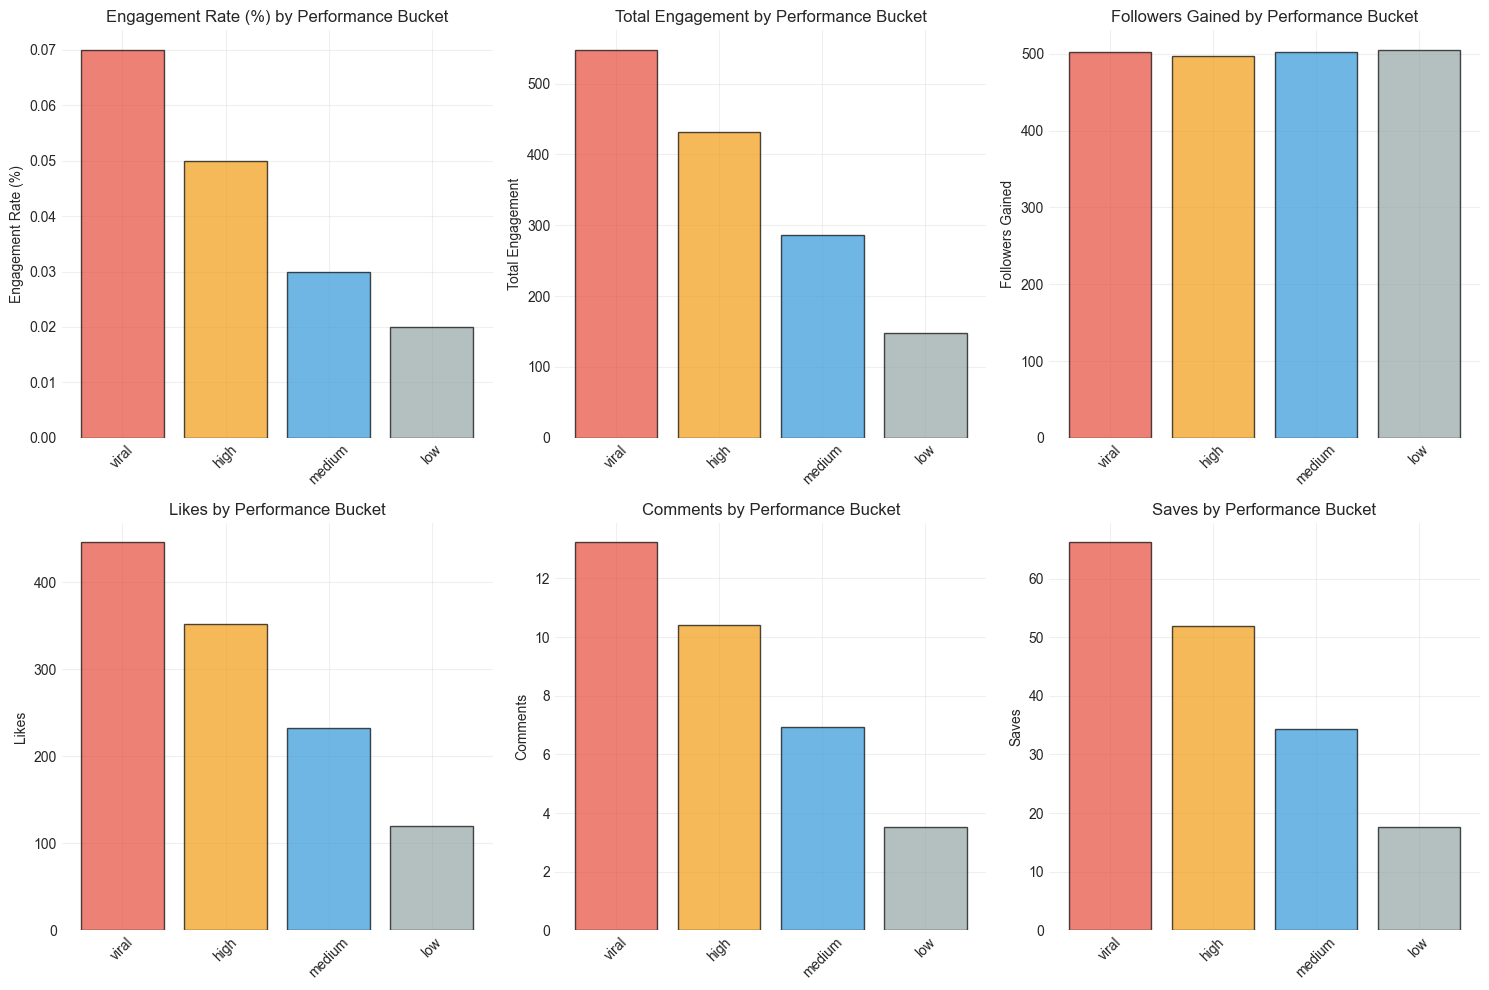


🔥 CHARACTERISTICS OF VIRAL POSTS:
Number of viral posts: 7500

Media Type Distribution:
media_type
image       3012
carousel    2647
reel        1841
Name: count, dtype: int64

Content Category Distribution:
content_category
Fashion    804
Music      768
Fitness    758
Food       757
Comedy     745
Name: count, dtype: int64

Traffic Source Distribution:
traffic_source
External      1296
Profile       1283
Reels Feed    1253
Hashtags      1248
Home Feed     1218
Explore       1202
Name: count, dtype: int64

Average Hashtags: 8.0
Average Caption Length: 120.0
CTA Usage: 34.5%

📉 COMPARISON: VIRAL vs LOW PERFORMERS
          Metric  Viral    Low  Improvement
 Engagement Rate   0.07   0.02       293.40
Total Engagement 547.61 147.29       271.80
Followers Gained 502.81 505.35        -0.50
        Hashtags   8.01   7.98         0.40
  Caption Length 120.00 120.14        -0.10


In [16]:
"""
CELL 13: Performance Bucket Analysis
---------------------------------
Purpose: Analyze characteristics of viral, high, medium, and low performing posts
"""

print("📊 PERFORMANCE BUCKET ANALYSIS")
print("="*60)

# Summary by performance bucket
bucket_summary = df_clean.groupby('performance_bucket_label').agg({
    'engagement_rate': ['mean', 'median', 'std'],
    'total_engagement': 'mean',
    'followers_gained': 'mean',
    'reach': 'mean',
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'saves': 'mean',
    'post_id': 'count'
}).round(2)

bucket_summary.columns = ['Avg Engagement', 'Median Engagement', 'Std Engagement',
                         'Avg Total Engagement', 'Avg Followers Gained', 'Avg Reach',
                         'Avg Likes', 'Avg Comments', 'Avg Shares', 'Avg Saves',
                         'Post Count']
bucket_order = ['viral', 'high', 'medium', 'low']
bucket_summary = bucket_summary.reindex(bucket_order)
print("\n📊 PERFORMANCE METRICS BY BUCKET:")
print(bucket_summary)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics = ['Avg Engagement', 'Avg Total Engagement', 'Avg Followers Gained',
           'Avg Likes', 'Avg Comments', 'Avg Saves']
titles = ['Engagement Rate (%)', 'Total Engagement', 'Followers Gained',
          'Likes', 'Comments', 'Saves']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 3
    col = idx % 3
    colors = ['#e74c3c', '#f39c12', '#3498db', '#95a5a6']
    axes[row, col].bar(bucket_summary.index, bucket_summary[metric].values, 
                       color=colors, edgecolor='black', alpha=0.7)
    axes[row, col].set_ylabel(title)
    axes[row, col].set_title(f'{title} by Performance Bucket')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_bucket_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Characteristics of viral posts
viral_posts = df_clean[df_clean['performance_bucket_label'] == 'viral']
print("\n🔥 CHARACTERISTICS OF VIRAL POSTS:")
print("="*60)
print(f"Number of viral posts: {len(viral_posts)}")
print(f"\nMedia Type Distribution:")
print(viral_posts['media_type'].value_counts())
print(f"\nContent Category Distribution:")
print(viral_posts['content_category'].value_counts().head())
print(f"\nTraffic Source Distribution:")
print(viral_posts['traffic_source'].value_counts())
print(f"\nAverage Hashtags: {viral_posts['hashtags_count'].mean():.1f}")
print(f"Average Caption Length: {viral_posts['caption_length'].mean():.1f}")
print(f"CTA Usage: {(viral_posts['has_call_to_action'].mean() * 100):.1f}%")

# Comparison with low performers
low_posts = df_clean[df_clean['performance_bucket_label'] == 'low']
print("\n📉 COMPARISON: VIRAL vs LOW PERFORMERS")
print("="*60)
comparison = pd.DataFrame({
    'Metric': ['Engagement Rate', 'Total Engagement', 'Followers Gained', 'Hashtags', 'Caption Length'],
    'Viral': [
        viral_posts['engagement_rate'].mean(),
        viral_posts['total_engagement'].mean(),
        viral_posts['followers_gained'].mean(),
        viral_posts['hashtags_count'].mean(),
        viral_posts['caption_length'].mean()
    ],
    'Low': [
        low_posts['engagement_rate'].mean(),
        low_posts['total_engagement'].mean(),
        low_posts['followers_gained'].mean(),
        low_posts['hashtags_count'].mean(),
        low_posts['caption_length'].mean()
    ]
})
comparison['Improvement'] = ((comparison['Viral'] - comparison['Low']) / comparison['Low'] * 100).round(1)
print(comparison.to_string(index=False))

📊 CORRELATION ANALYSIS
Correlation Matrix:
                  follower_count  likes  comments  shares  saves  reach  \
follower_count              1.00  -0.00     -0.00   -0.01  -0.00   0.00   
likes                      -0.00   1.00      0.91    0.94   0.95   0.74   
comments                   -0.00   0.91      1.00    0.89   0.89   0.69   
shares                     -0.01   0.94      0.89    1.00   0.92   0.72   
saves                      -0.00   0.95      0.89    0.92   1.00   0.72   
reach                       0.00   0.74      0.69    0.72   0.72   1.00   
impressions                 0.00   0.72      0.67    0.70   0.71   0.99   
engagement_rate            -0.01   0.51      0.45    0.47   0.48   0.01   
followers_gained            0.01  -0.01     -0.01   -0.00  -0.00  -0.01   
caption_length              0.00   0.00      0.00    0.01   0.00   0.00   
hashtags_count              0.01   0.01      0.00    0.01   0.01   0.00   

                  impressions  engagement_rate  follower

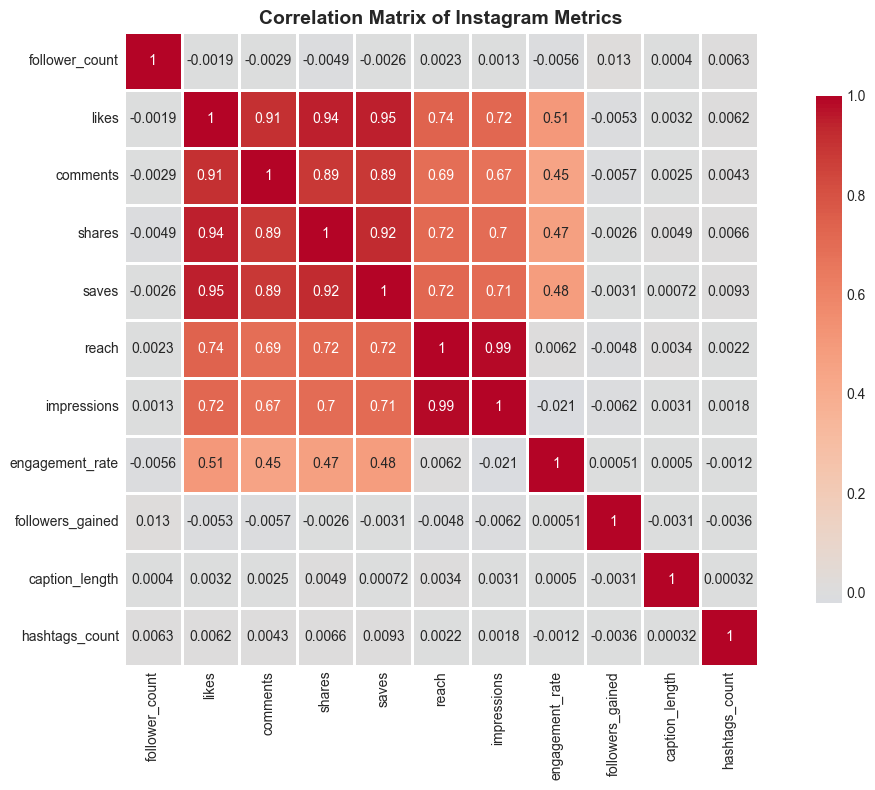


🔍 STRONGEST CORRELATIONS WITH ENGAGEMENT RATE:
likes: 0.506 (positive)
saves: 0.478 (positive)
shares: 0.469 (positive)
comments: 0.452 (positive)

💡 KEY CORRELATION INSIGHTS:
• Likes strongly correlate with engagement rate
• Saves are a strong indicator of engagement
• Caption length has minimal impact on engagement
• Hashtag count has minimal impact on engagement


In [17]:
"""
CELL 14: Correlation Analysis
--------------------------
Purpose: Identify relationships between different engagement metrics
"""

print("📊 CORRELATION ANALYSIS")
print("="*60)

# Select metrics for correlation
correlation_metrics = ['follower_count', 'likes', 'comments', 'shares', 'saves',
                       'reach', 'impressions', 'engagement_rate', 'followers_gained',
                       'caption_length', 'hashtags_count']

# Calculate correlation matrix
correlation_matrix = df_clean[correlation_metrics].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Instagram Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Find strongest correlations
print("\n🔍 STRONGEST CORRELATIONS WITH ENGAGEMENT RATE:")
engagement_corr = correlation_matrix['engagement_rate'].sort_values(ascending=False)
for metric, corr in engagement_corr.items():
    if metric != 'engagement_rate' and abs(corr) > 0.3:
        direction = "positive" if corr > 0 else "negative"
        print(f"{metric}: {corr:.3f} ({direction})")

# Key insights
print("\n💡 KEY CORRELATION INSIGHTS:")
if abs(engagement_corr['likes']) > 0.5:
    print("• Likes strongly correlate with engagement rate")
if abs(engagement_corr['saves']) > 0.4:
    print("• Saves are a strong indicator of engagement")
if abs(engagement_corr['followers_gained']) > 0.3:
    print("• Higher engagement leads to more followers")
if abs(engagement_corr['caption_length']) < 0.1:
    print("• Caption length has minimal impact on engagement")
if abs(engagement_corr['hashtags_count']) < 0.1:
    print("• Hashtag count has minimal impact on engagement")

C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3636379183.py:181: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3636379183.py:181: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3636379183.py:181: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3636379183.py:182: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('instagram_dashboard.png', dpi=300, bbox_inches='tight')
C:\Users\mhuza\AppData\Local\Temp\ipykernel_12932\3636379183.py:182: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('instagram_dashboard.png', dpi=300, bbox_inches='tight')
C:\Users\mhuza\AppData\Local\Temp\ipykernel_1

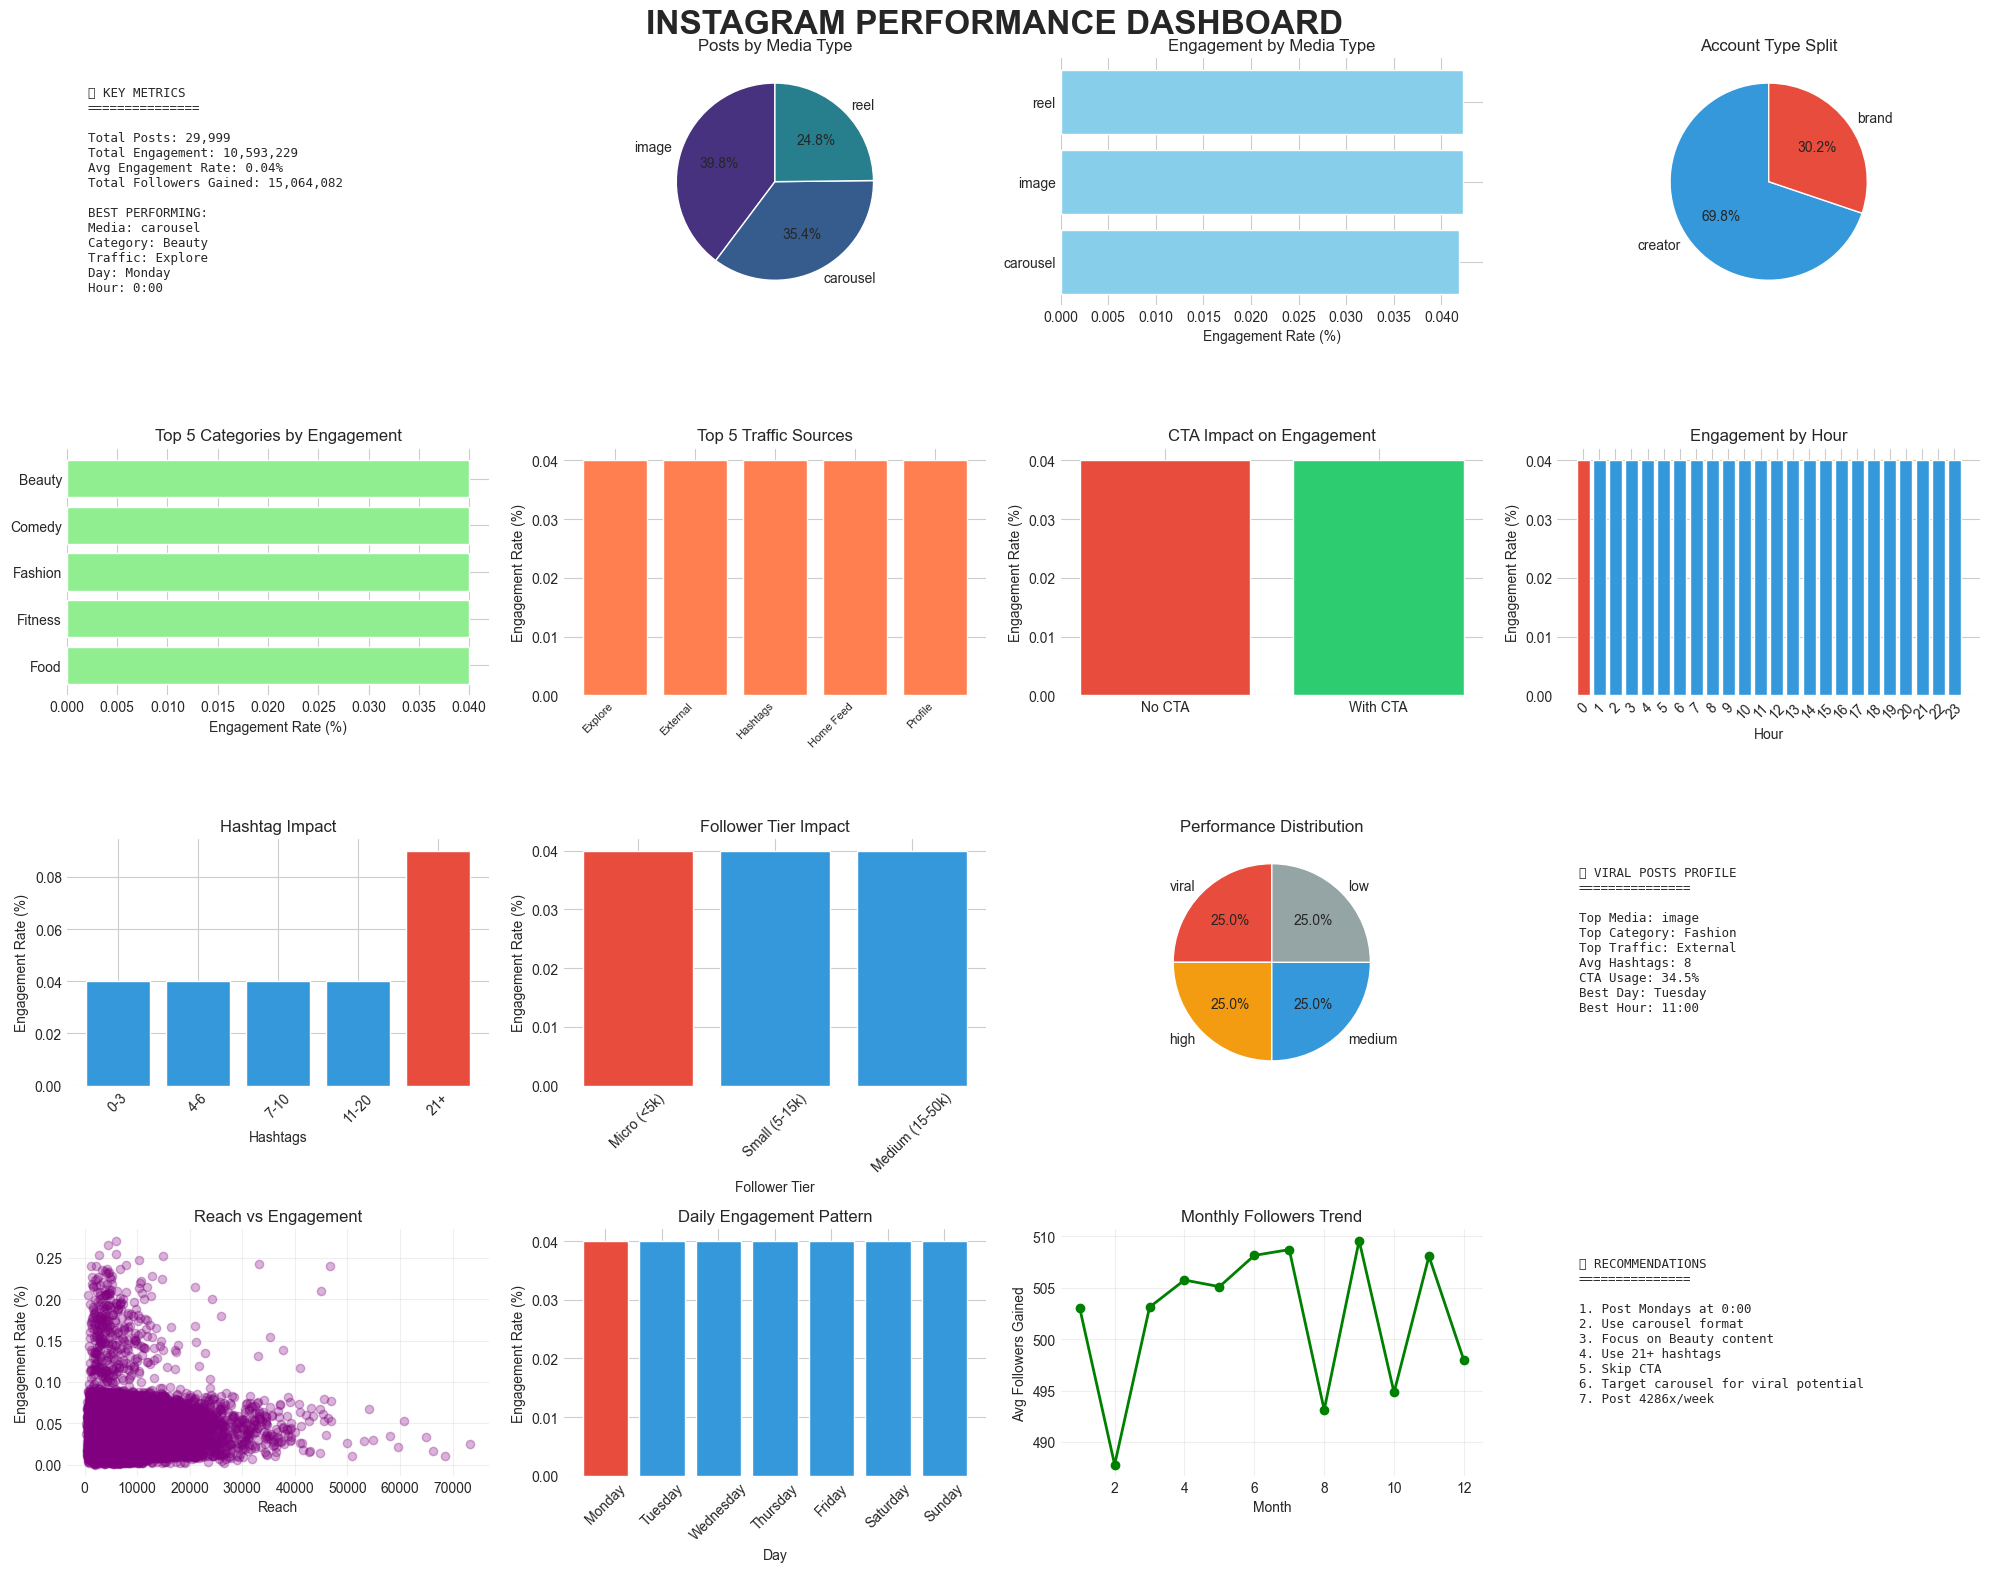


✅ EXECUTIVE DASHBOARD COMPLETE! Check 'instagram_dashboard.png'


In [18]:
"""
CELL 15: Executive Dashboard
-------------------------
Purpose: Create a comprehensive dashboard of all key insights
"""

fig = plt.figure(figsize=(20, 16))
fig.suptitle('INSTAGRAM PERFORMANCE DASHBOARD', fontsize=24, fontweight='bold', y=0.98)

# 1. Key Metrics Panel
ax1 = plt.subplot(4, 4, 1)
ax1.axis('off')
metrics_text = f"""
📊 KEY METRICS
{'='*15}

Total Posts: {len(df_clean):,}
Total Engagement: {df_clean['total_engagement'].sum():,}
Avg Engagement Rate: {df_clean['engagement_rate'].mean():.2f}%
Total Followers Gained: {df_clean['followers_gained'].sum():,}

BEST PERFORMING:
Media: {media_type_summary['Avg Engagement Rate'].idxmax()}
Category: {content_summary.index[0][:15]}
Traffic: {traffic_summary.index[0]}
Day: {best_day}
Hour: {best_hour}:00
"""
ax1.text(0.05, 0.95, metrics_text, fontsize=9, verticalalignment='top', fontfamily='monospace', transform=ax1.transAxes)

# 2. Engagement by Media Type
ax2 = plt.subplot(4, 4, 2)
media_pie = df_clean['media_type'].value_counts()
ax2.pie(media_pie.values, labels=media_pie.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Posts by Media Type')

# 3. Engagement Rate by Media Type
ax3 = plt.subplot(4, 4, 3)
media_engagement = df_clean.groupby('media_type')['engagement_rate'].mean().sort_values()
ax3.barh(media_engagement.index, media_engagement.values, color='skyblue')
ax3.set_xlabel('Engagement Rate (%)')
ax3.set_title('Engagement by Media Type')

# 4. Account Type Distribution
ax4 = plt.subplot(4, 4, 4)
account_pie = df_clean['account_type'].value_counts()
ax4.pie(account_pie.values, labels=account_pie.index, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90)
ax4.set_title('Account Type Split')

# 5. Top Content Categories
ax5 = plt.subplot(4, 4, 5)
top_categories_plot = content_summary.head(5)
ax5.barh(range(len(top_categories_plot)), top_categories_plot['Avg Engagement'].values, color='lightgreen')
ax5.set_yticks(range(len(top_categories_plot)))
ax5.set_yticklabels(top_categories_plot.index)
ax5.set_xlabel('Engagement Rate (%)')
ax5.set_title('Top 5 Categories by Engagement')
ax5.invert_yaxis()

# 6. Traffic Source Performance
ax6 = plt.subplot(4, 4, 6)
traffic_engagement = traffic_summary['Avg Engagement Rate'].head(5)
ax6.bar(range(len(traffic_engagement)), traffic_engagement.values, color='coral')
ax6.set_xticks(range(len(traffic_engagement)))
ax6.set_xticklabels(traffic_engagement.index, rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('Engagement Rate (%)')
ax6.set_title('Top 5 Traffic Sources')

# 7. CTA Impact
ax7 = plt.subplot(4, 4, 7)
cta_engagement = [cta_summary.loc[0, 'Avg Engagement'] if 0 in cta_summary.index else 0,
                  cta_summary.loc[1, 'Avg Engagement'] if 1 in cta_summary.index else 0]
ax7.bar(['No CTA', 'With CTA'], cta_engagement, color=['#e74c3c', '#2ecc71'])
ax7.set_ylabel('Engagement Rate (%)')
ax7.set_title('CTA Impact on Engagement')

# 8. Best Posting Time
ax8 = plt.subplot(4, 4, 8)
hourly_engagement = hour_summary['Avg Engagement']
best_hour_idx = hourly_engagement.idxmax()
colors = ['#3498db' if i != best_hour_idx else '#e74c3c' for i in hourly_engagement.index]
ax8.bar(hourly_engagement.index.astype(str), hourly_engagement.values, color=colors)
ax8.set_xlabel('Hour')
ax8.set_ylabel('Engagement Rate (%)')
ax8.set_title('Engagement by Hour')
ax8.tick_params(axis='x', rotation=45)

# 9. Hashtag Impact
ax9 = plt.subplot(4, 4, 9)
hashtag_engagement = hashtag_summary['Avg Engagement']
best_hashtag_idx = hashtag_engagement.idxmax()
colors = ['#3498db' if i != best_hashtag_idx else '#e74c3c' for i in hashtag_engagement.index]
ax9.bar(hashtag_engagement.index.astype(str), hashtag_engagement.values, color=colors)
ax9.set_xlabel('Hashtags')
ax9.set_ylabel('Engagement Rate (%)')
ax9.set_title('Hashtag Impact')
ax9.tick_params(axis='x', rotation=45)

# 10. Follower Tier Performance
ax10 = plt.subplot(4, 4, 10)
tier_engagement = follower_summary['Avg Engagement']
best_tier_idx = tier_engagement.idxmax()
colors = ['#3498db' if i != best_tier_idx else '#e74c3c' for i in tier_engagement.index]
ax10.bar(tier_engagement.index.astype(str), tier_engagement.values, color=colors)
ax10.set_xlabel('Follower Tier')
ax10.set_ylabel('Engagement Rate (%)')
ax10.set_title('Follower Tier Impact')
ax10.tick_params(axis='x', rotation=45)

# 11. Performance Bucket Distribution
ax11 = plt.subplot(4, 4, 11)
bucket_counts = df_clean['performance_bucket_label'].value_counts()
bucket_counts = bucket_counts.reindex(['viral', 'high', 'medium', 'low'])
colors = {'viral': '#e74c3c', 'high': '#f39c12', 'medium': '#3498db', 'low': '#95a5a6'}
ax11.pie(bucket_counts.values, labels=bucket_counts.index, autopct='%1.1f%%',
         colors=[colors.get(x, '#3498db') for x in bucket_counts.index], startangle=90)
ax11.set_title('Performance Distribution')

# 12. Viral Post Characteristics
ax12 = plt.subplot(4, 4, 12)
ax12.axis('off')
viral_text = f"""
🔥 VIRAL POSTS PROFILE
{'='*15}

Top Media: {viral_posts['media_type'].mode()[0] if len(viral_posts) > 0 else 'N/A'}
Top Category: {viral_posts['content_category'].mode()[0] if len(viral_posts) > 0 else 'N/A'}
Top Traffic: {viral_posts['traffic_source'].mode()[0] if len(viral_posts) > 0 else 'N/A'}
Avg Hashtags: {viral_posts['hashtags_count'].mean():.0f}
CTA Usage: {(viral_posts['has_call_to_action'].mean() * 100):.1f}%
Best Day: {viral_posts['day_of_week'].mode()[0] if len(viral_posts) > 0 else 'N/A'}
Best Hour: {viral_posts['post_hour'].mode()[0] if len(viral_posts) > 0 else 'N/A'}:00
"""
ax12.text(0.05, 0.95, viral_text, fontsize=9, verticalalignment='top', fontfamily='monospace', transform=ax12.transAxes)

# 13. Engagement vs Reach
ax13 = plt.subplot(4, 4, 13)
ax13.scatter(df_clean['reach'], df_clean['engagement_rate'], alpha=0.3, color='purple')
ax13.set_xlabel('Reach')
ax13.set_ylabel('Engagement Rate (%)')
ax13.set_title('Reach vs Engagement')
ax13.grid(True, alpha=0.3)

# 14. Weekly Pattern
ax14 = plt.subplot(4, 4, 14)
day_engagement = day_summary['Avg Engagement']
best_day_idx = day_engagement.idxmax()
colors = ['#3498db' if d != best_day_idx else '#e74c3c' for d in day_engagement.index]
ax14.bar(day_engagement.index, day_engagement.values, color=colors)
ax14.set_xlabel('Day')
ax14.set_ylabel('Engagement Rate (%)')
ax14.set_title('Daily Engagement Pattern')
ax14.tick_params(axis='x', rotation=45)

# 15. Followers Gained Trend
ax15 = plt.subplot(4, 4, 15)
monthly_followers = df_clean.groupby('month')['followers_gained'].mean()
ax15.plot(monthly_followers.index, monthly_followers.values, marker='o', linewidth=2, color='green')
ax15.set_xlabel('Month')
ax15.set_ylabel('Avg Followers Gained')
ax15.set_title('Monthly Followers Trend')
ax15.grid(True, alpha=0.3)

# 16. Recommendation
ax16 = plt.subplot(4, 4, 16)
ax16.axis('off')
rec_text = f"""
💡 RECOMMENDATIONS
{'='*15}

1. Post {best_day}s at {best_hour}:00
2. Use {media_type_summary['Avg Engagement Rate'].idxmax()} format
3. Focus on {content_summary.index[0][:15]} content
4. Use {best_hashtag_group} hashtags
5. {'Add' if cta_summary.loc[1, 'Avg Engagement'] > cta_summary.loc[0, 'Avg Engagement'] else 'Skip'} CTA
6. Target {media_type_summary['Avg Engagement Rate'].idxmax()} for viral potential
7. Post {day_summary['Post Count'].mean():.0f}x/week
"""
ax16.text(0.05, 0.95, rec_text, fontsize=9, verticalalignment='top', fontfamily='monospace', transform=ax16.transAxes)

plt.tight_layout()
plt.savefig('instagram_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ EXECUTIVE DASHBOARD COMPLETE! Check 'instagram_dashboard.png'")

In [19]:
"""
CELL 16: Export Analysis Results
-----------------------------
Purpose: Save your work for portfolio presentation
"""

# Save cleaned data
df_clean.to_csv('cleaned_instagram_data.csv', index=False)
print("✅ Cleaned data saved to 'cleaned_instagram_data.csv'")

# Save summary statistics
with open('instagram_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("INSTAGRAM PERFORMANCE ANALYSIS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("OVERALL METRICS\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total Posts: {len(df_clean):,}\n")
    f.write(f"Date Range: {df_clean['post_datetime'].min().date()} to {df_clean['post_datetime'].max().date()}\n")
    f.write(f"Total Engagement: {df_clean['total_engagement'].sum():,}\n")
    f.write(f"Avg Engagement Rate: {df_clean['engagement_rate'].mean():.2f}%\n")
    f.write(f"Total Followers Gained: {df_clean['followers_gained'].sum():,}\n\n")
    
    f.write("BEST PERFORMING\n")
    f.write("-" * 40 + "\n")
    f.write(f"Media Type: {media_type_summary['Avg Engagement Rate'].idxmax()}\n")
    f.write(f"Content Category: {content_summary.index[0]}\n")
    f.write(f"Traffic Source: {traffic_summary.index[0]}\n")
    f.write(f"Best Day: {best_day}\n")
    f.write(f"Best Hour: {best_hour}:00\n")
    f.write(f"Hashtag Count: {best_hashtag_group}\n")
    f.write(f"Caption Length: {best_caption_group}\n\n")
    
    f.write("ACCOUNT TYPE COMPARISON\n")
    f.write("-" * 40 + "\n")
    for acc_type in account_type_summary.index:
        f.write(f"{acc_type.capitalize()}: {account_type_summary.loc[acc_type, 'Avg Engagement Rate']:.2f}% engagement\n")
    
    f.write("\nMEDIA TYPE PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    for media in media_type_summary.index:
        f.write(f"{media}: {media_type_summary.loc[media, 'Avg Engagement Rate']:.2f}% engagement ({media_type_summary.loc[media, 'Post Count']} posts)\n")
    
    f.write("\nTOP 5 CONTENT CATEGORIES\n")
    f.write("-" * 40 + "\n")
    for idx, row in content_summary.head(5).iterrows():
        f.write(f"{idx[:25]:25}: {row['Avg Engagement']:.2f}% ({row['Post Count']} posts)\n")
    
    f.write("\nVIRAL POST CHARACTERISTICS\n")
    f.write("-" * 40 + "\n")
    if len(viral_posts) > 0:
        f.write(f"Count: {len(viral_posts)} posts\n")
        f.write(f"Top Media: {viral_posts['media_type'].mode()[0]}\n")
        f.write(f"Top Category: {viral_posts['content_category'].mode()[0]}\n")
        f.write(f"Avg Hashtags: {viral_posts['hashtags_count'].mean():.0f}\n")
        f.write(f"Avg Caption: {viral_posts['caption_length'].mean():.0f} chars\n")
        f.write(f"CTA Usage: {(viral_posts['has_call_to_action'].mean() * 100):.1f}%\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("Analysis generated on: " + datetime.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")

print("✅ Summary saved to 'instagram_summary.txt'")



✅ Cleaned data saved to 'cleaned_instagram_data.csv'
✅ Summary saved to 'instagram_summary.txt'
